# 2026-08-30 Paper II Q4: spatial asymmetry of surviving star formation

**Question:** does the resolved SFR response align with an independently determined
RPS direction, even when the whole surviving population is suppressed?

This is the **first pass, steps 1--8**.
It keeps the live sample, selection, geometry, pre-peak control and normalisation
from `20260829_check_surviving_SF_distribution.ipynb`, then adds two residual maps,
independent wind metadata, a close-to-peak map gallery, hemisphere contrasts, and
random-angle spin tests. Angular stacks, dipoles, radial matching, directional
SF-survival fractions and stage inference are deliberately deferred.

The reference notebook is not executed or modified at runtime: its required code
is embedded here. All figures and tables remain in this notebook by default.
FITS products are read only.

**Required external input:** independent upwind/tail PAs with their tracer,
reference, quality and uncertainty. No such catalogue was found in `further`
when this notebook was created. Missing directions are **not** inferred from the
SFR maps, disc PA, or the direction toward the cluster centre. Residual maps
remain useful without a wind PA; physical leading/trailing inference does not.

**VIVA follow-up:** at the user's request, Chung et al. (2009) Appendix A and
the five relevant atlas panels were inspected. An additional exploratory section
tests coarse literature-morphology axes for four galaxies. These are **not adopted
wind measurements** and do not populate the independent primary catalogue.
NGC4694 receives no candidate wind direction because the cited H I interpretation
favours a different physical origin. The Q3 stage labels remain unchanged.


## 1. Q3 configuration and first-pass Q4 controls

In [1]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
DATA_ROOT = PROJECT_ROOT / "v3tk_v7.6.8"
CATALOG_PATH = PROJECT_ROOT / "mauve_master_wiki_newclass.fits"
GEOMETRY_PATH = PROJECT_ROOT / "MAUVE_effective_radii.csv"
GALAXY_COLOR_PATH = PROJECT_ROOT / "MAUVE_galaxy_colors.dat"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "paper2_Q4_spatial_asymmetry"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
DIAGNOSTIC_DIR = OUTPUT_DIR / "diagnostics"

MASS_FILE_PATTERN = "{galid}_spatial_binning_maps_further.fits"
SFR_FILE_PATTERNS = (
    "{galid}_gas_bin_maps_further.fits",
    "{galid}_gas_BIN_maps_further.fits",
)
EW_FILE_PATTERNS = (
    "{galid}_proxy_EW_maps_further.fits",
    "{galid}_proxy_EW_maps.fits",
)
MASK_FILE_PATTERN = "{galid}_mask.fits"

MASS_HDU = "LOGMASS_SURFACE_DENSITY"
BIN_HDU_MASS = "BINID"
BIN_HDU_GAS = "BIN_ID"
SFR_HDU_PRIMARY = "LOGSFR_SURFACE_DENSITY_HII"
SFR_HDU_ROBUST = "LOGSFR_SURFACE_DENSITY_SF"
EW_HDU = "PROXY_EWHA"
EW_HA_MIN = 6.0
HALPHA_SIGMA_OBS_HDU = "HA6562_SIGMA"
HALPHA_SIGMA_CORR_HDU = "HA6562_SIGMA_CORR"
HALPHA_SIGMA_MAX = 45.0
MASK_TABLE_HDU = "MASKFILE"
MASK_COLUMN = "MASK"               # live nGIST convention: 0 usable, 1 masked

N_SIGMA_BINS = 12
SIGMA_RANGE = (6.0, 10.0)          # fixed common grid; unsupported bins are masked later
R_EDGES = __import__('numpy').arange(0.0, 1.6 + 0.2, 0.2)
N_RADIUS_2D_BINS = len(R_EDGES) - 1

I_MAX_PRIMARY = 80.0
I_MAX_ROBUSTNESS = (60.0, 65.0, 70.0, 80.0)
N_BOOTSTRAP = 10_000
N_PERMUTATIONS = 10_000
MIN_SF_GAL_PRIMARY = 50
NMIN_SENSITIVITY = (20, 50, 100)
EQUAL_GALAXY_VIOLIN_DRAWS = 2_000
RANDOM_SEED = 42

MIN_VALID_PIXELS_PER_BIN = 50
MIN_SF_PIXELS_PER_BIN = 20
MIN_GALAXIES_PER_STAGE_BIN = 3
MIN_GALAXIES_PER_2D_CELL = 3
WCS_TOLERANCE_ARCSEC = 0.05
STRICT_VALIDATION = True
EXCLUDED_GALAXIES = {}             # mapping GALID -> explicit reason; empty by design
SAVE_OUTPUTS = False             # enable only when figure/CSV output is explicitly requested

STAGE_ORDER = ("pre-peak", "close-to-peak", "post-peak")
STAGE_COLORS = {
    "pre-peak": "#2166ac",
    "close-to-peak": "#1a9850",
    "post-peak": "#d73027",
}

if SAVE_OUTPUTS:
    for path in (FIGURE_DIR, TABLE_DIR, DIAGNOSTIC_DIR):
        path.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data root: {DATA_ROOT}")
print(f"Outputs: {OUTPUT_DIR} (disabled unless SAVE_OUTPUTS=True)")
print("No additional inclination correction will be applied to either surface-density map.")
print(f"SF selection: finite HII/SF map + {EW_HDU}>{EW_HA_MIN:g} Angstrom + intrinsic Halpha sigma<{HALPHA_SIGMA_MAX:g} km/s")


# New Q4 controls; all Q3 scientific selection/control settings above are retained.
WIND_CATALOG_PATH = PROJECT_ROOT / 'MAUVE_RPS_wind_directions.csv'
WIND_PRIMARY_QUALITY = ('A', 'B')
MIN_SIDE_PIXELS = 20       # reporting support threshold, not independent observations
N_SPINS = 10_000
MIN_SPIN_VALID_FRACTION = 0.90
MIN_VALID_SPINS = 100
RESIDUAL_VLIM = 0.8       # dex, shared symmetric colour scale; clipping is reported
Z_VLIM = 2.0
SHOW_ALL_STAGE_MAPS = False
# This first pass only tests close-to-peak directions. Expand only after map review.
DIRECTIONAL_STAGES = ('close-to-peak',)
Q3_SOURCE_SHA256 = '484d1543828d909c1d779986e233121f562473473ea13eb68b418b6abca639b6'
print('Q4 first pass: close-to-peak maps and independently oriented hemisphere tests.')


Project root: /Users/Igniz/Desktop/ICRAR/further
Data root: /Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8
Outputs: /Users/Igniz/Desktop/ICRAR/further/outputs/paper2_Q4_spatial_asymmetry (disabled unless SAVE_OUTPUTS=True)
No additional inclination correction will be applied to either surface-density map.
SF selection: finite HII/SF map + PROXY_EWHA>6 Angstrom + intrinsic Halpha sigma<45 km/s
Q4 first pass: close-to-peak maps and independently oriented hemisphere tests.


## 2. Embedded Q3 data and control helpers

In [2]:
from __future__ import annotations

import math

import warnings

from dataclasses import dataclass

import matplotlib as mpl

import matplotlib.pyplot as plt

import numpy as np

import pandas as pd

from astropy.io import fits

from astropy.wcs import WCS

from IPython.display import display

from scipy.special import expit

RNG = np.random.default_rng(RANDOM_SEED)

mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.grid": False,
})

def save_table(frame: pd.DataFrame, filename: str) -> Path:
    path = TABLE_DIR / filename
    if SAVE_OUTPUTS:
        frame.to_csv(path, index=False)
    return path

def save_figure(fig, stem: str, *, diagnostic: bool = False):
    directory = DIAGNOSTIC_DIR if diagnostic else FIGURE_DIR
    if SAVE_OUTPUTS:
        fig.savefig(directory / f"{stem}.png", dpi=300, bbox_inches="tight")
        fig.savefig(directory / f"{stem}.pdf", bbox_inches="tight")

def normalise_stage_label(value) -> str:
    mapping = {
        1: "pre-peak", 1.0: "pre-peak", "1": "pre-peak",
        2: "close-to-peak", 2.0: "close-to-peak", "2": "close-to-peak",
        3: "post-peak", 3.0: "post-peak", "3": "post-peak",
        "prepeak": "pre-peak", "pre-peak": "pre-peak",
        "close-to-peak": "close-to-peak", "closetopeak": "close-to-peak",
        "near-peak": "close-to-peak", "postpeak": "post-peak",
        "post-peak": "post-peak",
    }
    key = value if isinstance(value, (int, float)) else str(value).strip().lower().replace(" ", "")
    if key not in mapping:
        raise ValueError(f"Unrecognised RPS/infall stage label: {value!r}")
    return mapping[key]

def first_existing(paths):
    for path in paths:
        if path.exists():
            return path
    return None

def load_fits_map(path: Path, hdu_name: str, *, return_header: bool = False):
    if not path.exists():
        raise FileNotFoundError(path)
    with fits.open(path, memmap=True) as hdul:
        names = {h.name.upper() for h in hdul}
        if hdu_name.upper() not in names:
            raise KeyError(f"{path}: missing HDU {hdu_name}; available={sorted(names)}")
        hdu = hdul[hdu_name]
        data = np.asarray(hdu.data, dtype=float).copy()
        header = hdu.header.copy()
    return (data, header) if return_header else data

def load_ngist_mask(path: Path, shape):
    if not path.exists():
        raise FileNotFoundError(path)
    with fits.open(path, memmap=True) as hdul:
        if MASK_TABLE_HDU not in hdul:
            raise KeyError(f"{path}: missing table HDU {MASK_TABLE_HDU}")
        table = hdul[MASK_TABLE_HDU].data
        if MASK_COLUMN not in table.names:
            raise KeyError(f"{path}: missing mask column {MASK_COLUMN}; available={table.names}")
        flat = np.asarray(table[MASK_COLUMN], dtype=int)
    if flat.size != int(np.prod(shape)):
        raise ValueError(f"{path}: mask length {flat.size} cannot reshape to {shape}")
    return flat.reshape(shape)

def celestial_wcs_separation_arcsec(header_a, header_b, shape):
    wa = WCS(header_a).celestial
    wb = WCS(header_b).celestial
    if not wa.has_celestial or not wb.has_celestial:
        return np.inf
    ny, nx = shape
    x = np.array([0, nx - 1, 0, nx - 1, (nx - 1) / 2])
    y = np.array([0, 0, ny - 1, ny - 1, (ny - 1) / 2])
    raa, deca = wa.pixel_to_world_values(x, y)
    rab, decb = wb.pixel_to_world_values(x, y)
    cosd = np.cos(np.deg2rad((deca + decb) / 2))
    return float(np.nanmax(np.hypot((raa - rab) * cosd, deca - decb)) * 3600.0)

def tangent_offsets_arcsec(ra_deg, dec_deg, ra0_deg, dec0_deg):
    ra, dec = np.deg2rad(ra_deg), np.deg2rad(dec_deg)
    ra0, dec0 = np.deg2rad(float(ra0_deg)), np.deg2rad(float(dec0_deg))
    dra = (ra - ra0 + np.pi) % (2 * np.pi) - np.pi
    cosc = np.sin(dec0) * np.sin(dec) + np.cos(dec0) * np.cos(dec) * np.cos(dra)
    with np.errstate(divide="ignore", invalid="ignore"):
        east = np.cos(dec) * np.sin(dra) / cosc
        north = (np.cos(dec0) * np.sin(dec) - np.sin(dec0) * np.cos(dec) * np.cos(dra)) / cosc
    return east * 206264.806247, north * 206264.806247

def calculate_deprojected_radius(shape, header, component_rows: pd.DataFrame):
    """Return min elliptical R/Re over physical components (union geometry for NGC4567_8)."""
    wcs = WCS(header).celestial
    if not wcs.has_celestial:
        raise ValueError("No celestial WCS available for radius calculation")
    yy, xx = np.indices(shape, dtype=float)
    ra, dec = wcs.pixel_to_world_values(xx, yy)
    radius = np.full(shape, np.inf, dtype=float)
    for _, row in component_rows.iterrows():
        east, north = tangent_offsets_arcsec(ra, dec, row.center_ra_deg, row.center_dec_deg)
        pa = np.deg2rad(float(row.pa_deg_east_of_north))
        major = east * np.sin(pa) + north * np.cos(pa)
        minor = east * np.cos(pa) - north * np.sin(pa)
        r = np.sqrt((major / float(row.a_re_arcsec)) ** 2 + (minor / float(row.b_re_arcsec)) ** 2)
        radius = np.minimum(radius, r)
    radius[~np.isfinite(radius)] = np.nan
    return radius

def make_valid_disc_mask(log_sigma_star, bin_id, ngist_mask, radius_re):
    return (
        np.isfinite(log_sigma_star)
        & np.isfinite(bin_id)
        & (ngist_mask == 0)
        & np.isfinite(radius_re)
    )

def intrinsic_sigma_from_maps(sigma_obs, sigma_corr):
    sigma_obs = np.asarray(sigma_obs, dtype=float)
    sigma_corr = np.asarray(sigma_corr, dtype=float)
    if sigma_obs.shape != sigma_corr.shape:
        raise ValueError(
            f"Observed/correction Halpha sigma shape mismatch: {sigma_obs.shape} vs {sigma_corr.shape}"
        )
    sigma2_intrinsic = sigma_obs**2 - sigma_corr**2
    sigma_intrinsic = np.full(sigma_obs.shape, np.nan, dtype=float)
    valid = np.isfinite(sigma2_intrinsic) & (sigma2_intrinsic > 0)
    sigma_intrinsic[valid] = np.sqrt(sigma2_intrinsic[valid])
    return sigma_intrinsic

def make_sf_mask(valid_disc_mask, log_sigma_sfr, ew_ha, halpha_sigma_intrinsic):
    """Project SF definition: HII/SF map + EW(Halpha)>6 A + intrinsic sigma<45 km/s."""
    return (
        valid_disc_mask
        & np.isfinite(log_sigma_sfr)
        & np.isfinite(ew_ha)
        & (ew_ha > EW_HA_MIN)
        & np.isfinite(halpha_sigma_intrinsic)
        & (halpha_sigma_intrinsic < HALPHA_SIGMA_MAX)
    )

def load_galaxy_maps(row, geometry, sfr_hdu=SFR_HDU_PRIMARY):
    mass, mass_header = load_fits_map(row.mass_path, MASS_HDU, return_header=True)
    mass_bin = load_fits_map(row.mass_path, BIN_HDU_MASS)
    gas_bin, gas_header = load_fits_map(row.sfr_path, BIN_HDU_GAS, return_header=True)
    sfr = load_fits_map(row.sfr_path, sfr_hdu)
    ew_ha = load_fits_map(row.ew_path, EW_HDU)
    halpha_sigma_obs = load_fits_map(row.sfr_path, HALPHA_SIGMA_OBS_HDU)
    halpha_sigma_corr = load_fits_map(row.sfr_path, HALPHA_SIGMA_CORR_HDU)
    shapes = {
        mass.shape, mass_bin.shape, gas_bin.shape, sfr.shape, ew_ha.shape,
        halpha_sigma_obs.shape, halpha_sigma_corr.shape,
    }
    if len(shapes) != 1:
        raise ValueError(f"{row.GALID}: map shape mismatch {sorted(shapes)}")
    wcs_sep = celestial_wcs_separation_arcsec(mass_header, gas_header, mass.shape)
    if not np.isfinite(wcs_sep) or wcs_sep > WCS_TOLERANCE_ARCSEC:
        raise ValueError(f"{row.GALID}: mass/gas WCS mismatch {wcs_sep:.4f} arcsec")
    ngist_mask = load_ngist_mask(row.mask_path, mass.shape)
    components = geometry.loc[geometry.notebook_product_id.eq(row.GALID)].copy()
    if components.empty:
        raise KeyError(f"{row.GALID}: no geometry rows")
    radius_re = calculate_deprojected_radius(mass.shape, mass_header, components)
    halpha_sigma_intrinsic = intrinsic_sigma_from_maps(halpha_sigma_obs, halpha_sigma_corr)
    valid = make_valid_disc_mask(mass, gas_bin, ngist_mask, radius_re)
    classification = valid & np.isfinite(sfr)
    sf = make_sf_mask(valid, sfr, ew_ha, halpha_sigma_intrinsic)
    return {
        "log_sigma_star": mass,
        "log_sigma_sfr": sfr,
        "ew_ha": ew_ha,
        "halpha_sigma_intrinsic": halpha_sigma_intrinsic,
        "mass_bin_id": mass_bin,
        "gas_bin_id": gas_bin,
        "ngist_mask": ngist_mask,
        "radius_re": radius_re,
        "valid_disc_mask": valid,
        "classification_mask": classification,
        "sf_mask": sf,
        "wcs_separation_arcsec": wcs_sep,
    }

def binned_indices(values, edges):
    return np.digitize(values, edges, right=False) - 1

def load_galaxy_colors(path):
    """Read the fixed, project-approved MAUVE galaxy colour mapping."""
    colors = {}
    for line in path.read_text().splitlines():
        fields = line.split()
        if not fields or fields[0].startswith("#") or fields[0] == "reserved":
            continue
        if fields[0] == "alias":
            colors[fields[1]] = fields[3]
        elif fields[0].isdigit():
            colors[fields[1]] = fields[3]
    return colors

def weighted_quantile(values, quantiles, weights=None):
    """Linear weighted quantiles; finite values with strictly positive weights only."""
    values = np.asarray(values, dtype=float)
    quantiles = np.atleast_1d(np.asarray(quantiles, dtype=float))
    if weights is None:
        weights = np.ones(values.size, dtype=float)
    weights = np.asarray(weights, dtype=float)
    keep = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    values, weights = values[keep], weights[keep]
    if values.size == 0:
        return np.full(quantiles.shape, np.nan)
    order = np.argsort(values)
    values, weights = values[order], weights[order]
    cumulative = np.cumsum(weights) - 0.5 * weights
    cumulative /= weights.sum()
    return np.interp(quantiles, cumulative, values, left=values[0], right=values[-1])

def interpolate_supported_reference(x, reference):
    supported = reference.loc[reference.supported & reference.reference.notna()].sort_values("sigma_center")
    if len(supported) < 2:
        return np.full(np.asarray(x).shape, np.nan)
    return np.interp(
        np.asarray(x, dtype=float),
        supported.sigma_center.to_numpy(),
        supported.reference.to_numpy(),
        left=np.nan,
        right=np.nan,
    )

def galaxy_metric_row(galid, stage, delta, z):
    delta = np.asarray(delta, dtype=float)
    z = np.asarray(z, dtype=float)
    delta = delta[np.isfinite(delta)]
    z = z[np.isfinite(z)]
    q16, q50, q84 = np.nanpercentile(delta, [16, 50, 84]) if delta.size else (np.nan,) * 3
    f_enh = np.mean(z > 1) if z.size else np.nan
    f_sup = np.mean(z < -1) if z.size else np.nan
    f_strong_enh = np.mean(z > 2) if z.size else np.nan
    f_strong_sup = np.mean(z < -2) if z.size else np.nan
    width = (q84 - q16) / 2 if delta.size else np.nan
    asymmetry = ((q84 - q50) - (q50 - q16)) / (q84 - q16) if delta.size and q84 > q16 else np.nan
    return {
        "GALID": galid, "stage": stage, "N_delta": delta.size, "N_z": z.size,
        "P16": q16, "M": q50, "P84": q84, "W": width,
        "f_enh": f_enh, "f_sup": f_sup,
        "f_strong_enh": f_strong_enh, "f_strong_sup": f_strong_sup,
        "F_tail": f_enh + f_sup, "A_tail": f_enh - f_sup, "S_asym": asymmetry,
    }


## 3. Live inventory and Q3 product-level sample

In [3]:
def read_master_catalogue(path):
    with fits.open(path) as hdul:
        table = hdul[1].data
        required = {"Galaxy", "logMstar", "class"}
        missing = required - set(table.names)
        if missing:
            raise KeyError(f"{path}: missing catalogue columns {sorted(missing)}")
        frame = pd.DataFrame({
            "galaxy": [str(v).strip() for v in table["Galaxy"]],
            "logMstar": np.asarray(table["logMstar"], dtype=float),
            "stage_code": np.asarray(table["class"], dtype=float),
        })
    frame["stage"] = frame.stage_code.map(normalise_stage_label)
    return frame


def discover_products(data_root):
    rows = []
    for folder in sorted(p for p in data_root.iterdir() if p.is_dir() and not p.name.endswith("_logs")):
        galid = folder.name
        mass = folder / MASS_FILE_PATTERN.format(galid=galid)
        sfr = first_existing([folder / p.format(galid=galid) for p in SFR_FILE_PATTERNS])
        ew = first_existing([folder / p.format(galid=galid) for p in EW_FILE_PATTERNS])
        mask = folder / MASK_FILE_PATTERN.format(galid=galid)
        rows.append({"GALID": galid, "mass_path": mass, "sfr_path": sfr, "ew_path": ew, "mask_path": mask})
    return pd.DataFrame(rows)


master = read_master_catalogue(CATALOG_PATH)
geometry = pd.read_csv(GEOMETRY_PATH)
required_geometry = {
    "galaxy", "notebook_product_id", "mauve_infall_stage", "center_ra_deg", "center_dec_deg",
    "inclination_deg", "pa_deg_east_of_north", "a_re_arcsec", "b_re_arcsec",
}
missing_geometry = required_geometry - set(geometry.columns)
if missing_geometry:
    raise KeyError(f"{GEOMETRY_PATH}: missing columns {sorted(missing_geometry)}")
if geometry.galaxy.duplicated().any():
    raise ValueError("Geometry catalogue contains duplicate physical-galaxy rows")

geometry = geometry.merge(master[["galaxy", "logMstar", "stage"]], on="galaxy", how="left", validate="one_to_one")
if geometry[["logMstar", "stage"]].isna().any().any():
    raise RuntimeError("Geometry/master catalogue merge left missing mass or stage values")
geometry["stage_from_geometry"] = geometry.mauve_infall_stage.map(normalise_stage_label)
if not geometry.stage.eq(geometry.stage_from_geometry).all():
    bad = geometry.loc[~geometry.stage.eq(geometry.stage_from_geometry), ["galaxy", "stage", "stage_from_geometry"]]
    raise RuntimeError(f"Stage disagreement between catalogues:\n{bad}")

product_meta = []
for galid, group in geometry.groupby("notebook_product_id", sort=False):
    if group.stage.nunique() != 1:
        raise RuntimeError(f"{galid}: physical components have inconsistent stages")
    product_meta.append({
        "GALID": galid,
        "components": ",".join(group.galaxy),
        "stage": group.stage.iloc[0],
        "logMstar_global": np.log10(np.sum(10 ** group.logMstar.to_numpy())),
        "inclination": group.inclination_deg.max(),
    })
product_meta = pd.DataFrame(product_meta)

inventory = product_meta.merge(discover_products(DATA_ROOT), on="GALID", how="outer", validate="one_to_one")
inventory["manual_exclusion_reason"] = inventory.GALID.map(EXCLUDED_GALAXIES).fillna("")
inventory["analysis_candidate"] = inventory.manual_exclusion_reason.eq("")

def path_exists(value):
    return isinstance(value, Path) and value.exists()

inventory["mass_exists"] = inventory.mass_path.map(path_exists)
inventory["sfr_exists"] = inventory.sfr_path.map(path_exists)
inventory["ew_exists"] = inventory.ew_path.map(path_exists)
inventory["mask_exists"] = inventory.mask_path.map(path_exists)
inventory["catalogue_complete"] = inventory[["stage", "logMstar_global", "inclination"]].notna().all(axis=1)
display(inventory[["GALID", "components", "stage", "logMstar_global", "inclination",
                   "mass_exists", "sfr_exists", "ew_exists", "mask_exists", "manual_exclusion_reason"]])
print("Inventory stage counts:", inventory.groupby("stage").GALID.nunique().to_dict())


Inventory stage counts: {'close-to-peak': 10, 'post-peak': 18, 'pre-peak': 11}


,GALID,components,stage,logMstar_global,inclination,mass_exists,sfr_exists,ew_exists,mask_exists,manual_exclusion_reason
0,IC3392,IC3392,post-peak,9.823572,68,True,True,True,True,
1,NGC4064,NGC4064,post-peak,10.046130,70,True,True,True,True,
2,NGC4189,NGC4189,pre-peak,9.734349,42,True,True,True,True,
3,NGC4192,NGC4192,pre-peak,10.764349,83,True,True,True,True,
4,NGC4216,NGC4216,post-peak,10.894349,90,False,False,False,False,
5,NGC4222,NGC4222,pre-peak,9.434349,90,True,True,True,True,
6,NGC4254,NGC4254,pre-peak,10.504350,39,True,True,True,True,
7,NGC4293,NGC4293,post-peak,10.526728,67,True,True,True,True,
8,NGC4294,NGC4294,pre-peak,9.364349,74,True,True,True,True,
9,NGC4298,NGC4298,close-to-peak,10.094349,52,True,True,True,True,


## 4. Q3 mask and product checks

The usable footprint is `MASK == 0`, finite stellar mass and gas-bin maps, and
finite catalogue geometry. Surviving SF additionally requires finite H II SFR,
EW(Halpha) > 6 Angstrom, and $0 < \sigma_{\mathrm{H}\alpha,\mathrm{int}} <45$
km/s, where the intrinsic width is the square root of observed squared minus
correction squared. No new inclination correction is applied to the densities.
The primary inclination cut remains $i<80^\circ$.

In [4]:
qc_rows = []
for row in inventory.itertuples(index=False):
    flags = []
    maps = None
    if not row.analysis_candidate:
        flags.append(f"manual_exclusion:{row.manual_exclusion_reason}")
    for label, exists in (("mass", row.mass_exists), ("sfr", row.sfr_exists), ("ew", row.ew_exists), ("mask", row.mask_exists)):
        if not exists:
            flags.append(f"missing_{label}_product")
    if not row.catalogue_complete:
        flags.append("missing_catalogue_metadata")
    if not flags:
        try:
            maps = load_galaxy_maps(row, geometry, SFR_HDU_PRIMARY)
            valid, sf = maps["valid_disc_mask"], maps["sf_mask"]
            classified = maps["classification_mask"]
            if np.any(sf & ~valid):
                flags.append("sf_not_subset_of_valid")
        except Exception as exc:
            flags.append(f"load_error:{type(exc).__name__}:{exc}")
    valid = maps["valid_disc_mask"] if maps is not None else np.zeros(0, dtype=bool)
    sf = maps["sf_mask"] if maps is not None else np.zeros(0, dtype=bool)
    classified = maps["classification_mask"] if maps is not None else np.zeros(0, dtype=bool)
    qc_rows.append({
        "GALID": row.GALID, "components": row.components, "stage": row.stage,
        "logMstar_global": row.logMstar_global, "inclination": row.inclination,
        "N_valid_stellar_pixels": int(valid.sum()),
        "N_HII_classified_pixels_before_EW_sigma": int(classified.sum()),
        "N_HII_EW_sigma_SF_pixels": int(sf.sum()),
        "selected_SF_area_fraction": float(sf.sum() / valid.sum()) if valid.size and valid.sum() else np.nan,
        "max_usable_R_over_Re": float(np.nanmax(maps["radius_re"][valid])) if maps is not None and valid.any() else np.nan,
        "logSigmaStar_min": float(np.nanmin(maps["log_sigma_star"][valid])) if maps is not None and valid.any() else np.nan,
        "logSigmaStar_max": float(np.nanmax(maps["log_sigma_star"][valid])) if maps is not None and valid.any() else np.nan,
        "logSigmaSFR_min": float(np.nanmin(maps["log_sigma_sfr"][sf])) if maps is not None and sf.any() else np.nan,
        "logSigmaSFR_max": float(np.nanmax(maps["log_sigma_sfr"][sf])) if maps is not None and sf.any() else np.nan,
        "wcs_separation_arcsec": maps["wcs_separation_arcsec"] if maps is not None else np.nan,
        "QC_flag": ";".join(flags) if flags else "OK",
    })

qc = pd.DataFrame(qc_rows)
save_table(qc, "Q4_sample_QC.csv")
display(qc)
failures = qc.loc[qc.QC_flag.str.contains("load_error|sf_not_subset_of_valid|missing_catalogue_metadata", regex=True)]
if STRICT_VALIDATION and not failures.empty:
    raise RuntimeError("Strict validation failed. Inspect the displayed qc table.")

primary = inventory.loc[
    inventory.analysis_candidate & inventory.GALID.isin(qc.loc[qc.QC_flag.eq("OK"), "GALID"])
    & inventory.inclination.lt(I_MAX_PRIMARY)
].copy()
print(f"Primary i < {I_MAX_PRIMARY:.0f} deg sample: {len(primary)} products")
print(primary.groupby("stage").GALID.nunique().reindex(STAGE_ORDER, fill_value=0).to_dict())
if (primary.groupby("stage").GALID.nunique().reindex(STAGE_ORDER, fill_value=0) < MIN_GALAXIES_PER_STAGE_BIN).any():
    raise RuntimeError("Primary sample lacks the minimum galaxy count in at least one stage")


Primary i < 80 deg sample: 26 products
{'pre-peak': 8, 'close-to-peak': 5, 'post-peak': 13}


,GALID,components,stage,logMstar_global,inclination,N_valid_stellar_pixels,N_HII_classified_pixels_before_EW_sigma,N_HII_EW_sigma_SF_pixels,selected_SF_area_fraction,max_usable_R_over_Re,logSigmaStar_min,logSigmaStar_max,logSigmaSFR_min,logSigmaSFR_max,wcs_separation_arcsec,QC_flag
0,IC3392,IC3392,post-peak,9.823572,68,94575,14845,13897,0.146942,3.084733,6.969276,9.253759,-2.814456,-0.912330,0.0,OK
1,NGC4064,NGC4064,post-peak,10.046130,70,179882,7820,3273,0.018195,1.939061,6.811374,9.428892,-2.878540,-0.062300,0.0,OK
2,NGC4189,NGC4189,pre-peak,9.734349,42,177204,100340,96364,0.543803,2.270596,6.873473,9.774550,-3.243131,0.244948,0.0,OK
3,NGC4192,NGC4192,pre-peak,10.764349,83,524447,153872,144333,0.275210,2.209738,6.785489,10.584879,-3.711207,-0.247443,0.0,OK
4,NGC4216,NGC4216,post-peak,10.894349,90,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,missing_mass_product;missing_sfr_product;missi...
5,NGC4222,NGC4222,pre-peak,9.434349,90,259670,44054,42249,0.162703,6.734879,5.144392,8.537164,-4.122338,-0.244437,0.0,OK
6,NGC4254,NGC4254,pre-peak,10.504350,39,1043477,684002,661963,0.634382,4.060766,6.261151,10.597720,-3.477444,0.371030,0.0,OK
7,NGC4293,NGC4293,post-peak,10.526728,67,261523,4957,471,0.001801,1.842599,7.243091,10.336573,-2.516239,-0.939601,0.0,OK
8,NGC4294,NGC4294,pre-peak,9.364349,74,179355,69207,68833,0.383781,3.404326,6.290771,8.630426,-3.560500,-0.557290,0.0,OK
9,NGC4298,NGC4298,close-to-peak,10.094349,52,498540,160650,144157,0.289158,2.927309,6.476232,9.372817,-3.286308,-0.183778,0.0,OK


## 5. Reconstruct the unchanged Q3 environmental reference

Use 12 bins over $6\leq\log\Sigma_\star<10$, with at least 20 SF pixels per
galaxy/bin and at least three pre-peak galaxies per control bin. The control
$f_{\rm pre}$ is the median of per-galaxy medians. The Q3 linear interpolation
between supported bin centres is retained with no extrapolation. A continuity
check below rejects an internal support gap rather than silently bridging it.

$$\Delta_{\rm env}=\log\Sigma_{\rm SFR}-f_{\rm pre}(\log\Sigma_\star),
\qquad z_{\rm env}=\Delta_{\rm env}/\sigma_{\rm pre}(\log\Sigma_\star).$$

$\sigma_{\rm pre}=(P_{84}-P_{16})/2$ uses the Q3 residual distribution in each
bin, giving each contributing pre-peak galaxy equal total weight. It is an
empirical control width, **not** a measurement error or a Gaussian significance.
Q3 eligibility is at least 50 finite $z$ values per galaxy.

In [5]:
sigma_edges = np.linspace(SIGMA_RANGE[0], SIGMA_RANGE[1], N_SIGMA_BINS + 1)
sigma_centres = (sigma_edges[:-1] + sigma_edges[1:]) / 2

spaxels = {}
reference_rows = []
for row in primary.itertuples(index=False):
    maps = load_galaxy_maps(row, geometry, SFR_HDU_PRIMARY)
    sf = maps["sf_mask"]
    x = maps["log_sigma_star"][sf].astype(np.float32)
    y = maps["log_sigma_sfr"][sf].astype(np.float32)
    finite = np.isfinite(x) & np.isfinite(y) & (x >= sigma_edges[0]) & (x < sigma_edges[-1])
    x, y = x[finite], y[finite]
    spaxels[row.GALID] = {"GALID": row.GALID, "stage": row.stage, "x": x, "y": y}
    bin_index = binned_indices(x, sigma_edges)
    for j in range(N_SIGMA_BINS):
        in_bin = bin_index == j
        n = int(in_bin.sum())
        reference_rows.append({
            "GALID": row.GALID, "stage": row.stage, "sigma_bin": j,
            "sigma_center": sigma_centres[j], "N_SF": n,
            "galaxy_median_logSigmaSFR": np.median(y[in_bin]) if n >= MIN_SF_PIXELS_PER_BIN else np.nan,
        })

reference_by_galaxy = pd.DataFrame(reference_rows)
prepeak_reference = (
    reference_by_galaxy.loc[reference_by_galaxy.stage.eq("pre-peak")]
    .groupby(["sigma_bin", "sigma_center"], as_index=False)
    .agg(
        reference=("galaxy_median_logSigmaSFR", "median"),
        galaxy_p16=("galaxy_median_logSigmaSFR", lambda values: values.quantile(0.16)),
        galaxy_p84=("galaxy_median_logSigmaSFR", lambda values: values.quantile(0.84)),
        Ngal=("galaxy_median_logSigmaSFR", "count"),
    )
)
prepeak_reference["supported"] = prepeak_reference.Ngal.ge(MIN_GALAXIES_PER_STAGE_BIN)

for galid, payload in spaxels.items():
    x, y = payload["x"], payload["y"]
    payload["bin_index"] = binned_indices(x, sigma_edges)
    payload["reference"] = interpolate_supported_reference(x, prepeak_reference).astype(np.float32)
    payload["delta"] = (y - payload["reference"]).astype(np.float32)

scatter_rows = []
for j in range(N_SIGMA_BINS):
    arrays, weights = [], []
    contributing = []
    for galid, payload in spaxels.items():
        if payload["stage"] != "pre-peak":
            continue
        use = (payload["bin_index"] == j) & np.isfinite(payload["delta"])
        values = payload["delta"][use]
        if values.size >= MIN_SF_PIXELS_PER_BIN:
            arrays.append(values)
            weights.append(np.full(values.size, 1.0 / values.size))
            contributing.append(galid)
    if len(arrays) >= MIN_GALAXIES_PER_STAGE_BIN:
        q16, q50, q84 = weighted_quantile(np.concatenate(arrays), [0.16, 0.50, 0.84], np.concatenate(weights))
    else:
        q16 = q50 = q84 = np.nan
    scatter_rows.append({
        "sigma_bin": j, "sigma_center": sigma_centres[j], "Ngal": len(arrays),
        "P16_delta_pre": q16, "P50_delta_pre": q50, "P84_delta_pre": q84,
        "sigma_pre": (q84 - q16) / 2 if np.isfinite(q84 - q16) and q84 > q16 else np.nan,
        "contributing_GALIDs": ",".join(contributing),
    })
control_scatter = pd.DataFrame(scatter_rows)

sigma_by_bin = control_scatter.set_index("sigma_bin").sigma_pre.to_dict()
metric_rows = []
for galid, payload in spaxels.items():
    sigma_control = np.array([sigma_by_bin.get(int(j), np.nan) for j in payload["bin_index"]], dtype=np.float32)
    payload["z"] = np.divide(
        payload["delta"], sigma_control,
        out=np.full(payload["delta"].shape, np.nan, dtype=np.float32),
        where=np.isfinite(sigma_control) & (sigma_control > 0),
    )
    metric_rows.append(galaxy_metric_row(galid, payload["stage"], payload["delta"], payload["z"]))

galaxy_metrics = pd.DataFrame(metric_rows)
galaxy_metrics["eligible_primary"] = galaxy_metrics.N_z.ge(MIN_SF_GAL_PRIMARY)
display(prepeak_reference)
display(control_scatter)
display(galaxy_metrics.sort_values(["stage", "GALID"]))
print("Eligible primary stage counts:", galaxy_metrics.loc[galaxy_metrics.eligible_primary].groupby("stage").GALID.nunique().reindex(STAGE_ORDER, fill_value=0).to_dict())

supported_ids = prepeak_reference.loc[prepeak_reference.supported, 'sigma_bin'].to_numpy()
if len(supported_ids) > 1 and np.any(np.diff(supported_ids) != 1):
    raise RuntimeError('Q3 control now has an internal support gap; review before Q4 inference.')
q3_metrics = galaxy_metrics.copy()
q4_sample = primary.loc[primary.GALID.isin(
    q3_metrics.loc[q3_metrics.eligible_primary, 'GALID'])].copy()
close_ids = q4_sample.loc[q4_sample.stage.eq('close-to-peak'), 'GALID'].tolist()
print('Current close-to-peak map targets:', close_ids)


Eligible primary stage counts: {'pre-peak': 8, 'close-to-peak': 5, 'post-peak': 13}
Current close-to-peak map targets: ['NGC4298', 'NGC4424', 'NGC4501', 'NGC4654', 'NGC4694']


,sigma_bin,sigma_center,reference,galaxy_p16,galaxy_p84,Ngal,supported
0,0,6.166667,NaN,NaN,NaN,0,False
1,1,6.500000,-2.754313,-3.347243,-2.413425,3,True
2,2,6.833333,-3.065042,-3.098908,-2.712723,3,True
3,3,7.166667,-2.849044,-3.086835,-2.570242,7,True
4,4,7.500000,-2.555174,-2.635979,-2.400502,8,True
5,5,7.833333,-2.212694,-2.379245,-2.035480,8,True
6,6,8.166667,-1.955101,-2.083862,-1.709616,8,True
7,7,8.500000,-1.608874,-1.952430,-1.415935,8,True
8,8,8.833333,-1.199692,-1.870747,-0.796550,7,True
9,9,9.166667,-0.784183,-1.053963,-0.458818,5,True


,sigma_bin,sigma_center,Ngal,P16_delta_pre,P50_delta_pre,P84_delta_pre,sigma_pre,contributing_GALIDs
0,0,6.166667,0,NaN,NaN,NaN,NaN,
1,1,6.500000,3,-0.719329,0.097661,0.622883,0.671106,"NGC4254,NGC4294,NGC4383"
2,2,6.833333,3,-0.129356,0.062958,0.581785,0.355571,"NGC4254,NGC4294,NGC4383"
3,3,7.166667,7,-0.409204,-0.152415,0.362723,0.385963,"NGC4189,NGC4254,NGC4294,NGC4321,NGC4351,NGC438..."
4,4,7.500000,8,-0.363400,-0.029560,0.415767,0.389584,"NGC4189,NGC4254,NGC4294,NGC4321,NGC4351,NGC438..."
5,5,7.833333,8,-0.380154,0.013184,0.492419,0.436286,"NGC4189,NGC4254,NGC4294,NGC4321,NGC4351,NGC438..."
6,6,8.166667,8,-0.357027,0.064757,0.550691,0.453859,"NGC4189,NGC4254,NGC4294,NGC4321,NGC4351,NGC438..."
7,7,8.500000,8,-0.413002,0.055137,0.534208,0.473605,"NGC4189,NGC4254,NGC4294,NGC4321,NGC4351,NGC438..."
8,8,8.833333,7,-0.573045,0.012378,0.641090,0.607067,"NGC4189,NGC4254,NGC4321,NGC4351,NGC4383,NGC453..."
9,9,9.166667,5,-0.405824,0.102433,0.565935,0.485879,"NGC4254,NGC4321,NGC4383,NGC4535,NGC4567_8"


,GALID,stage,N_delta,N_z,P16,M,P84,W,f_enh,f_sup,f_strong_enh,f_strong_sup,F_tail,A_tail,S_asym,eligible_primary
6,NGC4298,close-to-peak,144157,144157,-0.463901,-0.138488,0.303369,0.383635,0.102361,0.178000,0.015199,0.002761,0.280361,-0.075640,0.151764,True
14,NGC4424,close-to-peak,8994,8994,-0.435359,-0.039562,0.546909,0.491134,0.183678,0.148988,0.061485,0.001223,0.332666,0.034690,0.194117,True
17,NGC4501,close-to-peak,251936,251936,-0.576104,-0.242075,0.161408,0.368756,0.053569,0.243435,0.007633,0.004263,0.297004,-0.189866,0.094174,True
23,NGC4654,close-to-peak,342929,342929,-0.392063,-0.034693,0.472332,0.432198,0.185091,0.142400,0.050573,0.003412,0.327491,0.042691,0.173132,True
24,NGC4694,close-to-peak,1058,1058,-0.482931,-0.162338,0.261241,0.372086,0.041588,0.146503,0.000000,0.000000,0.188091,-0.104915,0.138388,True
0,IC3392,post-peak,13897,13897,-0.406470,-0.115160,0.248242,0.327356,0.054616,0.109088,0.000504,0.000000,0.163704,-0.054472,0.110114,True
1,NGC4064,post-peak,3273,3273,-0.398183,0.105470,0.635079,0.516631,0.207149,0.112741,0.033303,0.006722,0.319890,0.094409,0.025120,True
4,NGC4293,post-peak,471,471,-0.677362,-0.373043,0.337063,0.507213,0.084926,0.464968,0.000000,0.000000,0.549894,-0.380042,0.400015,True
9,NGC4380,post-peak,64097,64097,-0.790970,-0.536400,-0.179474,0.305748,0.011607,0.609717,0.001311,0.097477,0.621324,-0.598109,0.167385,True
11,NGC4394,post-peak,31915,31915,-0.744629,-0.504676,-0.129466,0.307581,0.017265,0.575873,0.001003,0.044493,0.593138,-0.558609,0.219870,True


### Interpreting the control

Positive $\Delta_{\rm env}$ means above the pre-peak reference, while negative
values mean below it. The control is internal to this sample, so it is not an
independent field-galaxy baseline. Differences in spatial sampling remain
possible even after removing the first-order stellar-density relation.

## 6. Within-galaxy reference and two-dimensional residual maps

For galaxy $g$, use its own SF median in each **same** stellar-density bin:

$$ f_g(c_j)=\mathrm{median}_g(\log\Sigma_{\rm SFR}\mid B_j),\qquad
\delta_{\rm local}=\log\Sigma_{\rm SFR}-f_g(\log\Sigma_\star). $$

This implements the bin-median local definition specified in the shared chat;
it is not a claim to have reproduced an unprovided Paper-1 code cell. Interpolate
only between adjacent supported centres (at least 20 pixels/bin), without
extrapolation or interpolation across gaps. The local relation uses all Q3 SF
pixels in the mass range, before any wind split. It is **not** a subtraction of
one galaxy-wide median, and it includes no additional radius term.

Environmental and local map support are reported separately. For hemisphere
contrasts of the two residuals, use the common finite $\Delta,z,\delta$ mask so
differences cannot arise merely from comparing different pixels. Also retain
environmental-only side metrics for the full Q3-supported population.

The combined `NGC4567_8` product retains the Q3 union geometry and product-level
control. Its two centres make a single directional split ambiguous; it is
excluded from direction inference unless a future component treatment is
explicitly adopted. This does not alter its role in the Q3 control.

In [6]:
def interpolate_contiguous(x, centres, values, support):
    x = np.asarray(x, dtype=float)
    result = np.full(x.shape, np.nan)
    for j in range(len(centres)-1):
        if support[j] and support[j+1]:
            take = (x >= centres[j]) & (x <= centres[j+1])
            result[take] = np.interp(x[take], centres[j:j+2], values[j:j+2])
    return result


spatial = {}
support_rows = []
for row in q4_sample.itertuples(index=False):
    maps = load_galaxy_maps(row, geometry, SFR_HDU_PRIMARY)
    _, header = load_fits_map(row.mass_path, MASS_HDU, return_header=True)
    shape = maps['log_sigma_star'].shape
    sf_flat = np.flatnonzero(maps['sf_mask'])
    x = maps['log_sigma_star'].ravel()[sf_flat].astype(np.float32)
    y = maps['log_sigma_sfr'].ravel()[sf_flat].astype(np.float32)
    keep = np.isfinite(x) & np.isfinite(y) & (x >= sigma_edges[0]) & (x < sigma_edges[-1])
    flat_index = sf_flat[keep]
    payload = spaxels[row.GALID]
    # Assert the exact Q3 ordering before projecting its residuals back to pixels.
    np.testing.assert_array_equal(x[keep], payload['x'])
    np.testing.assert_array_equal(y[keep], payload['y'])
    own = reference_by_galaxy.loc[reference_by_galaxy.GALID.eq(row.GALID)].sort_values('sigma_bin')
    own_values = own.galaxy_median_logSigmaSFR.to_numpy()
    own_supported = np.isfinite(own_values)
    local_reference = interpolate_contiguous(payload['x'], sigma_centres, own_values, own_supported)
    local = payload['y'].astype(float) - local_reference
    for key, values in [('delta_env', payload['delta']), ('z_env', payload['z']), ('delta_local', local)]:
        arr = np.full(shape, np.nan)
        arr.ravel()[flat_index] = values
        maps[key] = arr
    env = maps['sf_mask'] & np.isfinite(maps['delta_env']) & np.isfinite(maps['z_env'])
    joint = env & np.isfinite(maps['delta_local'])
    comp = geometry.loc[geometry.notebook_product_id.eq(row.GALID)].copy()
    yy, xx = np.indices(shape, dtype=float)
    ra, dec = WCS(header).celestial.pixel_to_world_values(xx, yy)
    if len(comp) == 1:
        c = comp.iloc[0]
        east, north = tangent_offsets_arcsec(ra, dec, c.center_ra_deg, c.center_dec_deg)
        pixel_pa = np.mod(np.rad2deg(np.arctan2(east, north)), 360)
        # A pixel exactly at the centre has no meaningful direction.
        pixel_pa[np.hypot(east, north) < 1e-8] = np.nan
    else:
        east = north = pixel_pa = np.full(shape, np.nan)
    maps.update(header=header, components=comp, east=east, north=north, pixel_pa=pixel_pa,
                environment_mask=env, joint_mask=joint,
                local_reference=local_reference, own_values=own_values,
                stage=row.stage, inclination=row.inclination)
    spatial[row.GALID] = maps
    support_rows.append(dict(GALID=row.GALID, stage=row.stage, inclination=row.inclination,
        N_Q3_mass_range=len(flat_index), N_env=int(env.sum()),
        N_local=int(np.isfinite(maps['delta_local']).sum()), N_joint=int(joint.sum()),
        joint_fraction_of_env=float(joint.sum()/env.sum()) if env.any() else np.nan,
        N_local_supported_bins=int(own_supported.sum()),
        multiple_centres=len(comp) != 1,
        N_env_colour_clipped=int(np.count_nonzero(np.abs(maps['delta_env']) > RESIDUAL_VLIM)),
        N_local_colour_clipped=int(np.count_nonzero(np.abs(maps['delta_local']) > RESIDUAL_VLIM))))
map_support = pd.DataFrame(support_rows)
display(map_support)
print('Q3 vector-to-map identity verified for every eligible product.')


Q3 vector-to-map identity verified for every eligible product.


,GALID,stage,inclination,N_Q3_mass_range,N_env,N_local,N_joint,joint_fraction_of_env,N_local_supported_bins,multiple_centres,N_env_colour_clipped,N_local_colour_clipped
0,IC3392,post-peak,68,13897,13897,13868,13868,0.997913,5,False,99,143
1,NGC4064,post-peak,70,3273,3273,3213,3213,0.981668,4,False,396,287
2,NGC4189,pre-peak,42,96364,96364,96357,96357,0.999927,6,False,4539,4823
3,NGC4254,pre-peak,39,661963,658873,658991,658873,1.000000,11,False,96842,52759
4,NGC4293,post-peak,67,471,471,310,310,0.658174,2,False,4,11
5,NGC4294,pre-peak,74,68833,68833,68798,68798,0.999492,7,False,3982,2476
6,NGC4298,close-to-peak,52,144157,144157,144120,144120,0.999743,7,False,4504,5808
7,NGC4321,pre-peak,32,454131,454110,454129,454110,1.000000,9,False,33236,34168
8,NGC4351,pre-peak,48,30711,30711,30613,30613,0.996809,6,False,552,320
9,NGC4380,post-peak,61,64097,64097,61825,61825,0.964554,5,False,9723,1436


### Map-support interpretation

The joint mask may be smaller than the environmental mask where a galaxy's own
median relation has sparse support. Those missing pixels are not zero residuals
and must not be interpreted as quenched regions. Positive local residuals can
occur in an entirely environmentally suppressed galaxy. Neither residual alone
establishes ram-pressure causation.

## 7. Independent wind metadata (explicit missing-input gate)

Supply a CSV at `WIND_CATALOG_PATH`, or edit `WIND_ROWS` below. There are no
fabricated example galaxy angles. Required columns are:

| Column | Meaning |
|---|---|
| `GALID` | Exact Q3 product ID |
| `pa_deg` | Sky PA in degrees, east of north, in [0, 360) |
| `pa_kind` | `upwind` or `tail`; tail is converted by adding 180 degrees |
| `quality` | A: direct HI/kinematic/modelling evidence; B: other independent gas/radio evidence; C: indirect |
| `tracer`, `reference` | Evidence tracer and traceable citation or URL |
| `independent_of_sfr` | `True` only if the axis was not chosen from these SFR residuals |
| `uncertainty_kind` | `gaussian`, `uniform`, or `unknown` |
| `pa_sigma_deg` | Positive 1-sigma width for `gaussian` |
| `pa_half_width_deg` | Positive half-width about `pa_deg` for `uniform` |
| `notes` | Provenance, direction ambiguity, or other caveats |

Missing uncertainties may be labelled `unknown` but are never replaced with zero.
Nominal-PA results then remain exploratory. This first pass records uncertainties;
propagating them is deferred with the later robustness work in the shared plan.
Only independently sourced A/B directions enter the nominal directional results.
No automatic literature/cluster-centric PA substitutions are made.

In [7]:
WIND_ROWS = []

WIND_COLUMNS = ['GALID', 'pa_deg', 'pa_kind', 'quality', 'tracer', 'reference',
    'independent_of_sfr', 'uncertainty_kind', 'pa_sigma_deg', 'pa_half_width_deg', 'notes']
if WIND_CATALOG_PATH.exists():
    if WIND_ROWS:
        raise ValueError('Use either the wind CSV or WIND_ROWS, not both.')
    wind_inputs = pd.read_csv(WIND_CATALOG_PATH)
    wind_input_origin = str(WIND_CATALOG_PATH)
else:
    wind_inputs = pd.DataFrame(WIND_ROWS, columns=WIND_COLUMNS)
    wind_input_origin = 'inline WIND_ROWS' if WIND_ROWS else 'missing: no adopted directions supplied'
if set(WIND_COLUMNS) - set(wind_inputs.columns):
    raise ValueError(f'Wind catalogue missing columns: {set(WIND_COLUMNS)-set(wind_inputs.columns)}')
if wind_inputs.GALID.duplicated().any():
    raise ValueError('Duplicate wind GALIDs; resolve conflicting directions explicitly.')
unknown_ids = set(wind_inputs.GALID) - set(inventory.GALID)
if unknown_ids:
    raise ValueError(f'Wind IDs not present in the Q3 inventory: {sorted(unknown_ids)}')


def clean_text(value):
    return '' if pd.isna(value) else str(value).strip()


direction_rows = []
for galid, maps in spatial.items():
    match = wind_inputs.loc[wind_inputs.GALID.eq(galid)]
    rec = dict(GALID=galid, stage=maps['stage'], pa_upwind_deg=np.nan,
               quality='', tracer='', reference='', uncertainty_kind='unknown',
               pa_sigma_deg=np.nan, pa_half_width_deg=np.nan, notes='')
    problems = []
    if match.empty:
        problems.append('missing_independent_wind_PA')
    else:
        w = match.iloc[0]
        rec.update({key: clean_text(w[key]) for key in
                    ('quality','tracer','reference','uncertainty_kind','notes')})
        rec['quality'] = rec['quality'].upper()
        kind = clean_text(w.pa_kind).lower()
        pa = pd.to_numeric(w.pa_deg, errors='coerce')
        if kind not in ('upwind', 'tail') or not np.isfinite(pa) or not (0 <= pa < 360):
            problems.append('invalid_PA_or_convention')
        else:
            rec['pa_upwind_deg'] = float((pa + (180 if kind == 'tail' else 0)) % 360)
        if rec['quality'] not in WIND_PRIMARY_QUALITY:
            problems.append('not_primary_direction_quality')
        if not rec['tracer'] or not rec['reference']:
            problems.append('missing_direction_provenance')
        if clean_text(w.independent_of_sfr).lower() != 'true':
            problems.append('direction_not_confirmed_independent')
        uk = rec['uncertainty_kind'].lower()
        rec['uncertainty_kind'] = uk
        for key in ('pa_sigma_deg', 'pa_half_width_deg'):
            rec[key] = pd.to_numeric(w[key], errors='coerce')
        if uk not in ('gaussian', 'uniform', 'unknown'):
            problems.append('invalid_uncertainty_kind')
        if uk in ('gaussian', 'uniform'):
            width = rec['pa_sigma_deg' if uk == 'gaussian' else 'pa_half_width_deg']
            if not np.isfinite(width) or not (0 < width <= 180):
                problems.append('invalid_PA_uncertainty')
    if len(maps['components']) != 1:
        problems.append('multiple_centres_direction_deferred')
    rec['direction_usable'] = not problems
    rec['in_first_pass'] = maps['stage'] in DIRECTIONAL_STAGES
    rec['direction_status'] = ';'.join(problems) if problems else 'nominal_PA_ready'
    direction_rows.append(rec)
wind_status = pd.DataFrame(direction_rows)
display(wind_status)
print('Wind input:', wind_input_origin)
print('Nominal directions available in first-pass stages:',
      int((wind_status.direction_usable & wind_status.in_first_pass).sum()))


Wind input: missing: no adopted directions supplied
Nominal directions available in first-pass stages: 0


,GALID,stage,pa_upwind_deg,quality,tracer,reference,uncertainty_kind,pa_sigma_deg,pa_half_width_deg,notes,direction_usable,in_first_pass,direction_status
0,IC3392,post-peak,NaN,,,,unknown,NaN,NaN,,False,False,missing_independent_wind_PA
1,NGC4064,post-peak,NaN,,,,unknown,NaN,NaN,,False,False,missing_independent_wind_PA
2,NGC4189,pre-peak,NaN,,,,unknown,NaN,NaN,,False,False,missing_independent_wind_PA
3,NGC4254,pre-peak,NaN,,,,unknown,NaN,NaN,,False,False,missing_independent_wind_PA
4,NGC4293,post-peak,NaN,,,,unknown,NaN,NaN,,False,False,missing_independent_wind_PA
5,NGC4294,pre-peak,NaN,,,,unknown,NaN,NaN,,False,False,missing_independent_wind_PA
6,NGC4298,close-to-peak,NaN,,,,unknown,NaN,NaN,,False,True,missing_independent_wind_PA
7,NGC4321,pre-peak,NaN,,,,unknown,NaN,NaN,,False,False,missing_independent_wind_PA
8,NGC4351,pre-peak,NaN,,,,unknown,NaN,NaN,,False,False,missing_independent_wind_PA
9,NGC4380,post-peak,NaN,,,,unknown,NaN,NaN,,False,False,missing_independent_wind_PA


## 8. Close-to-peak map gallery before inference

Each row shows usable stellar density, selected SF density, environmental
residual, within-galaxy residual, and Q3-standardised residual. Coordinates are
sky east/north offsets in arcsec, displayed with north up and east left.
The ellipse is $R_e$ and the dashed line is the disc major axis. A sourced
upwind arrow and the perpendicular leading/trailing boundary appear only when
the independent-direction gate passes. Otherwise the title explicitly states
that the wind PA is missing or ineligible. All residual panels use the same
symmetric colour scale; coloured saturation is a display choice only.

Dashed arrows, when present, show only the provisional VIVA compass hypotheses below; solid arrows require an adopted direction.

### VIVA evidence and provisional compass directions

Source: [Chung et al. 2009, AJ 138, 1741, Appendix A and atlas](https://www.astro.yale.edu/viva/papers/viva_atlas.pdf),
[DOI](https://doi.org/10.1088/0004-6256/138/6/1741).
Page numbers below refer to the **80-page author PDF**, not journal pagination.
The named H I panels and their sky-coordinate orientation were visually checked.

| Galaxy | H I evidence and caveat (paraphrased) | Text / atlas PDF pages | Provisional upwind sector |
|---|---|---|---|
| NGC4298 | NW extension and SE compression; nearby NGC4302 makes tides plausible. | 17 / 37 | SE, centre 135 deg |
| NGC4424 | Southern tail bends SE; strongly disturbed stellar structure indicates a merger/collision complication. | 20 / 52 | N, centre 0 deg |
| NGC4501 | SW truncation/compression and NE diffuse gas. The paragraph later says SE, creating an internal directional inconsistency. | 21 / 56 | SW, centre 225 deg, cross-checked below |
| NGC4654 | SE tail and NW compression; both ram pressure and gravitational interaction are discussed. | 25--26 / 73 | NW, centre 315 deg |
| NGC4694 | H I connects to VCC2062; the authors favour accretion and reject an RPS explanation. | 26 / 75; Fig. A19 | No wind axis assigned |

For NGC4501, [Vollmer et al. 2008](https://arxiv.org/abs/0801.4874)
independently describes SW motion/compression. This corroborates the SW sector;
we do not assume the conflicting wording in Chung is a measured PA or silently
correct it. The current MAUVE/Q3 stage classification is not changed to the
historical stage language used in that paper.

**Analyst choices, not literature measurements:** 0/135/225/315 degrees encode
the compass descriptions. A +/-45 degree sector is a deliberately broad
sensitivity bracket, not a published error bar, fitted uncertainty, or posterior.
The axis is not adjusted after viewing SFR residuals. Mixed tidal/RPS systems
cannot support a clean causal claim from alignment alone. The primary wind
catalogue remains empty until an adopted, sourced direction is entered above.

In [8]:
RUN_VIVA_EXPLORATORY = True
VIVA_CANDIDATES = pd.DataFrame([
    dict(GALID='NGC4298', pa_upwind_deg=135.0, half_width_deg=45.0,
         evidence='HI compression SE / extension NW', caveat='Nearby companion; tidal ambiguity',
         text_page='17', atlas_page=37),
    dict(GALID='NGC4424', pa_upwind_deg=0.0, half_width_deg=45.0,
         evidence='Opposite southern HI tail', caveat='Merger/collision; curved tail',
         text_page='20', atlas_page=52),
    dict(GALID='NGC4501', pa_upwind_deg=225.0, half_width_deg=45.0,
         evidence='SW compression; Vollmer 2008 corroboration', caveat='Chung SW/SE wording conflict; no measured PA',
         text_page='21', atlas_page=56),
    dict(GALID='NGC4654', pa_upwind_deg=315.0, half_width_deg=45.0,
         evidence='HI compression NW / tail SE', caveat='Mixed ram pressure and gravitational interaction',
         text_page='25-26', atlas_page=73),
])
VIVA_CANDIDATES['source'] = 'https://www.astro.yale.edu/viva/papers/viva_atlas.pdf'
VIVA_CANDIDATES['angle_status'] = 'Analyst compass-sector hypothesis; NOT an adopted PA'
display(VIVA_CANDIDATES)
print('NGC4694: no RPS direction inferred from the accretion-related HI extension.')

NGC4694: no RPS direction inferred from the accretion-related HI extension.


,GALID,pa_upwind_deg,half_width_deg,evidence,caveat,text_page,atlas_page,source,angle_status
0,NGC4298,135.0,45.0,HI compression SE / extension NW,Nearby companion; tidal ambiguity,17,37,https://www.astro.yale.edu/viva/papers/viva_at...,Analyst compass-sector hypothesis; NOT an adop...
1,NGC4424,0.0,45.0,Opposite southern HI tail,Merger/collision; curved tail,20,52,https://www.astro.yale.edu/viva/papers/viva_at...,Analyst compass-sector hypothesis; NOT an adop...
2,NGC4501,225.0,45.0,SW compression; Vollmer 2008 corroboration,Chung SW/SE wording conflict; no measured PA,21,56,https://www.astro.yale.edu/viva/papers/viva_at...,Analyst compass-sector hypothesis; NOT an adop...
3,NGC4654,315.0,45.0,HI compression NW / tail SE,Mixed ram pressure and gravitational interaction,25-26,73,https://www.astro.yale.edu/viva/papers/viva_at...,Analyst compass-sector hypothesis; NOT an adop...


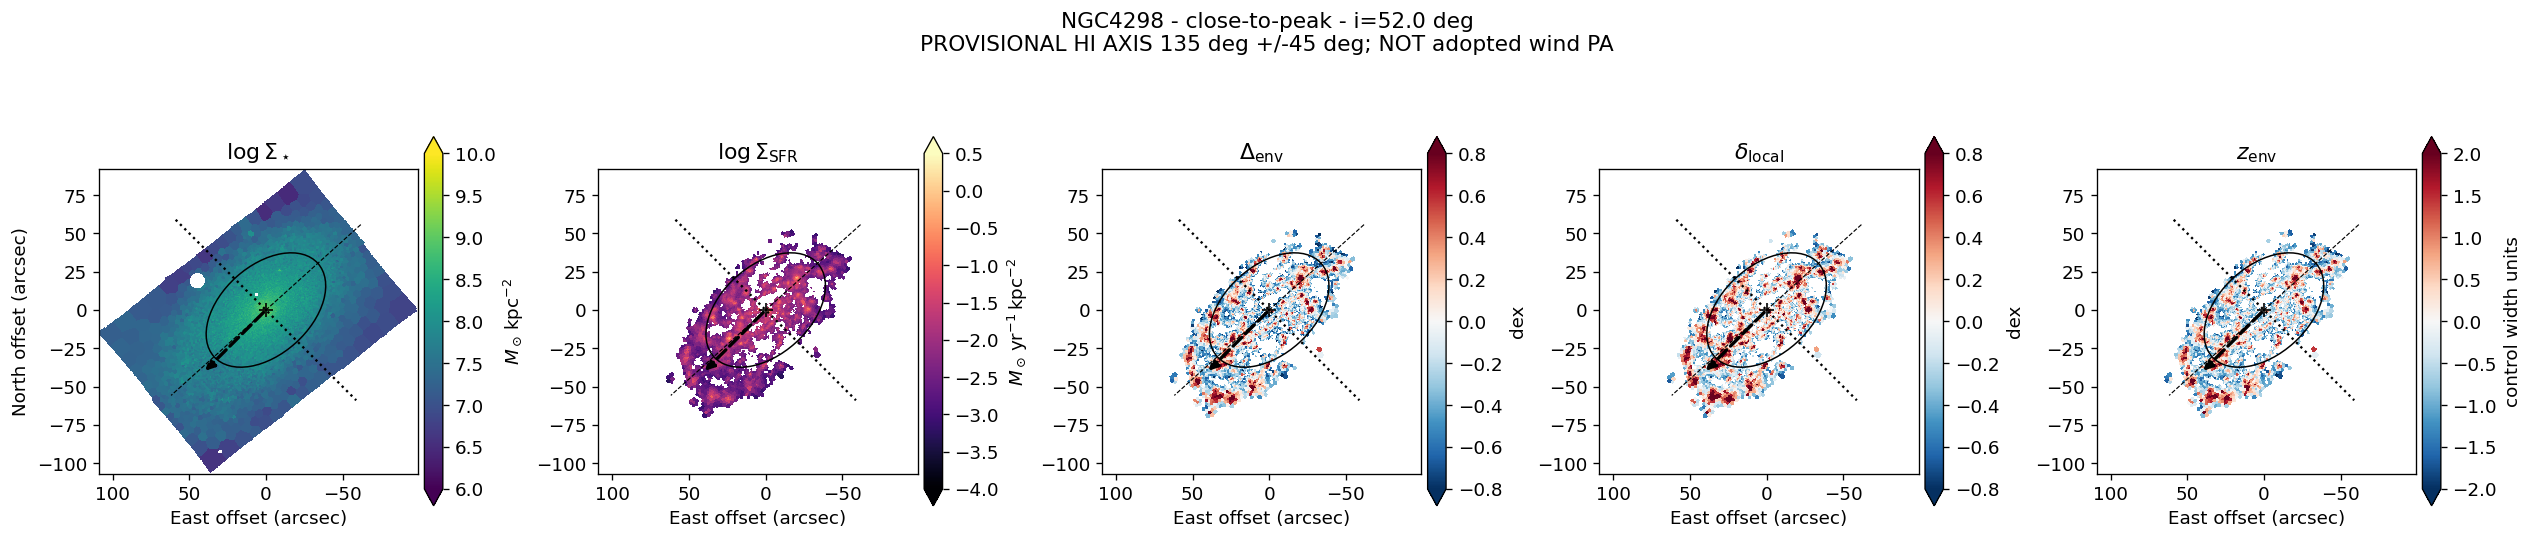

**Map interpretation -- NGC4298:** the supported environmental median is -0.138 dex (144,157 environmental pixels; 144,120 local pixels). The local map removes the galaxy-specific stellar-density trend; red patches there do not by themselves imply enhancement above the pre-peak control. **Any dashed arrow is only the literature-derived compass hypothesis; see the exploratory tests, not a primary wind result.**

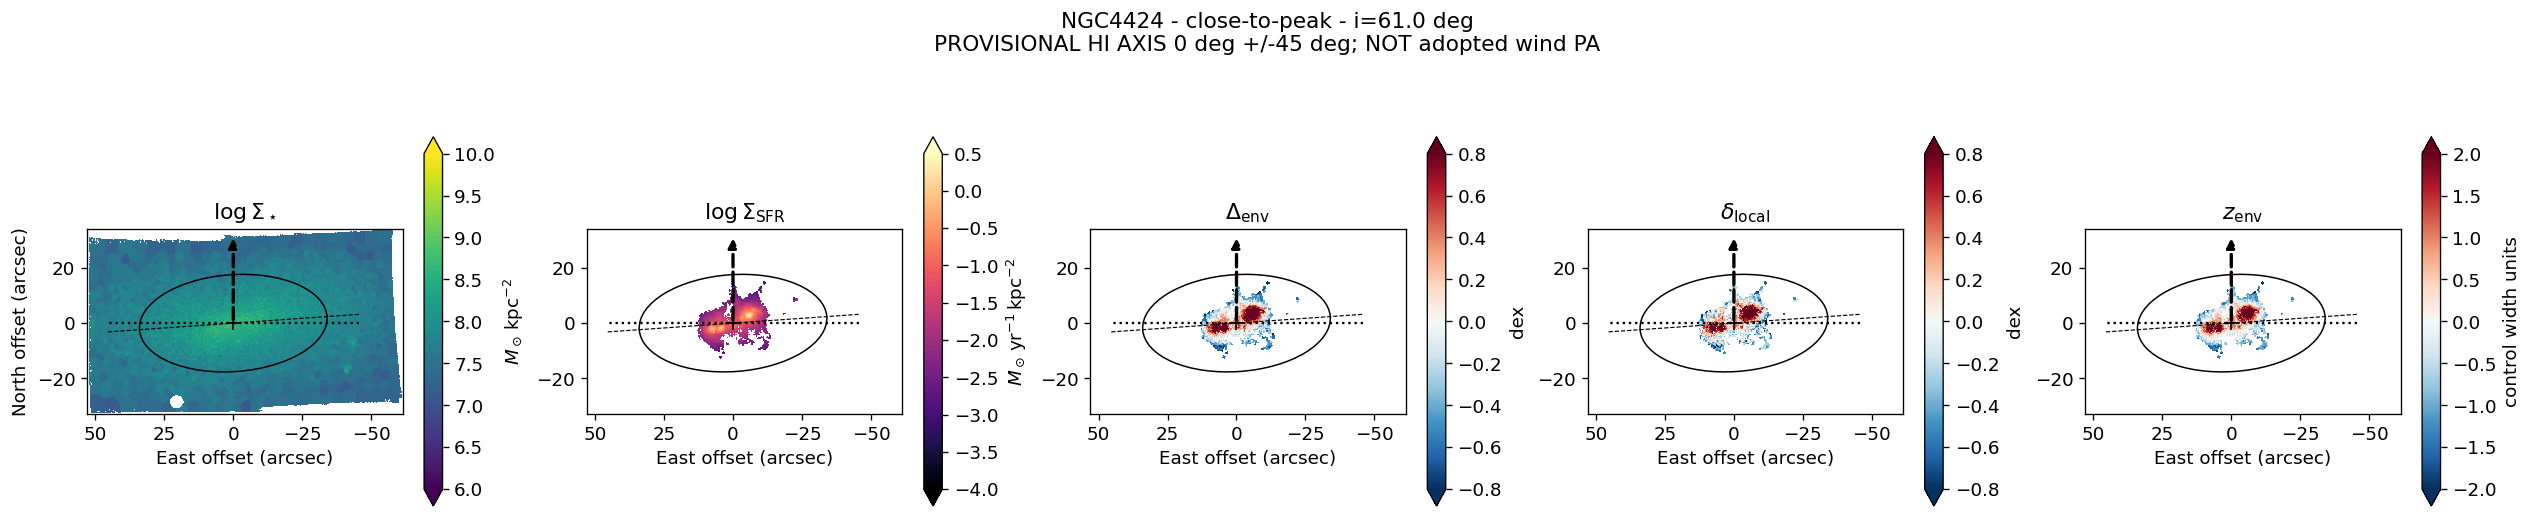

**Map interpretation -- NGC4424:** the supported environmental median is -0.040 dex (8,994 environmental pixels; 8,868 local pixels). The local map removes the galaxy-specific stellar-density trend; red patches there do not by themselves imply enhancement above the pre-peak control. **Any dashed arrow is only the literature-derived compass hypothesis; see the exploratory tests, not a primary wind result.**

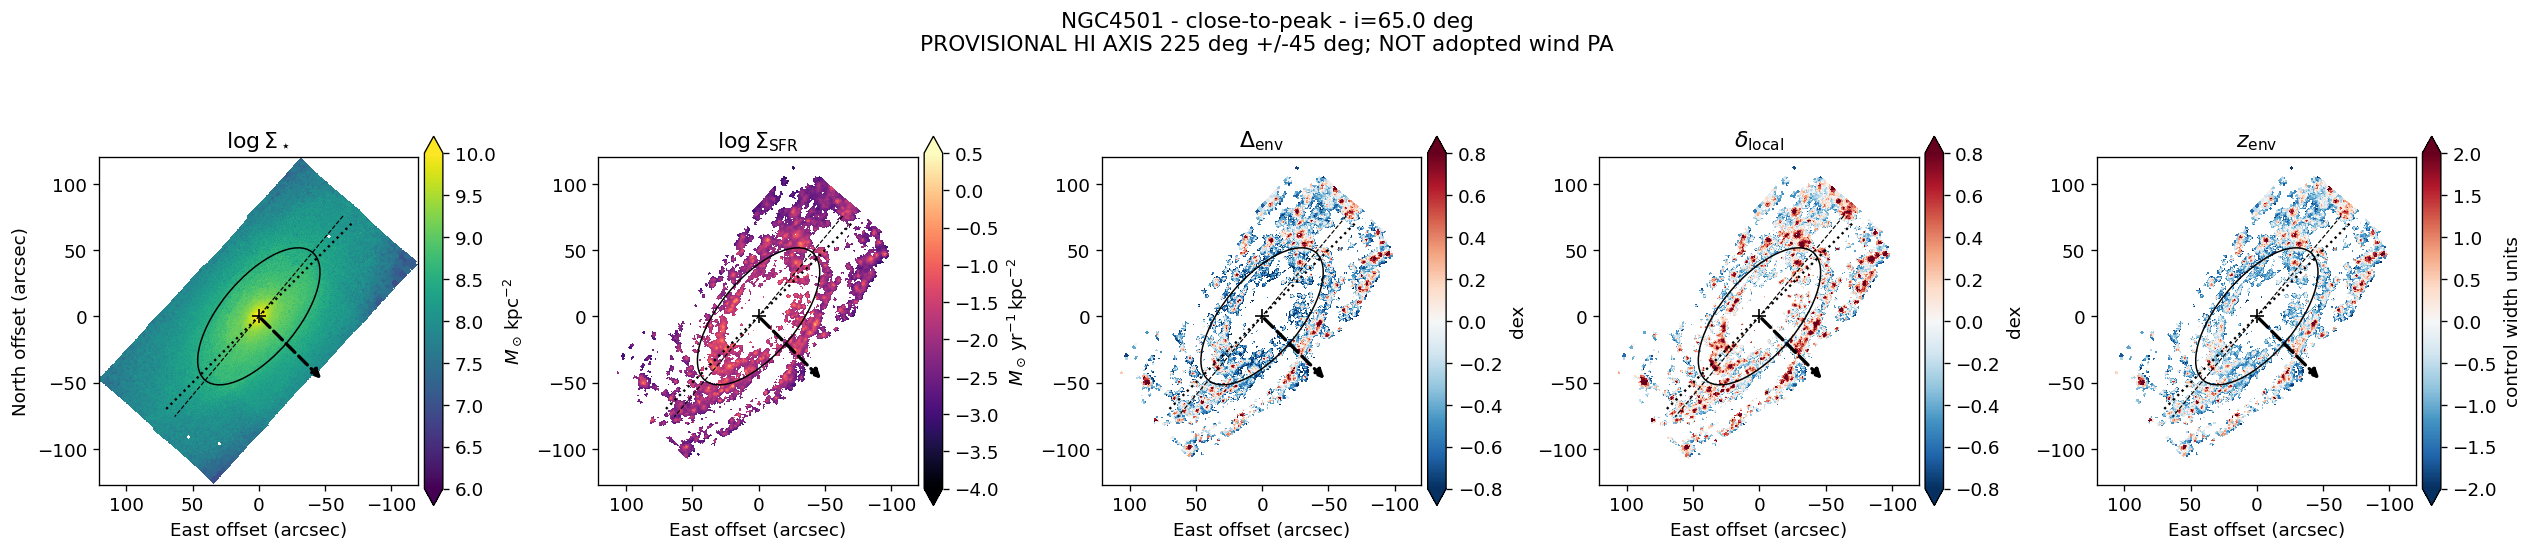

**Map interpretation -- NGC4501:** the supported environmental median is -0.242 dex (251,936 environmental pixels; 251,898 local pixels). The local map removes the galaxy-specific stellar-density trend; red patches there do not by themselves imply enhancement above the pre-peak control. **Any dashed arrow is only the literature-derived compass hypothesis; see the exploratory tests, not a primary wind result.**

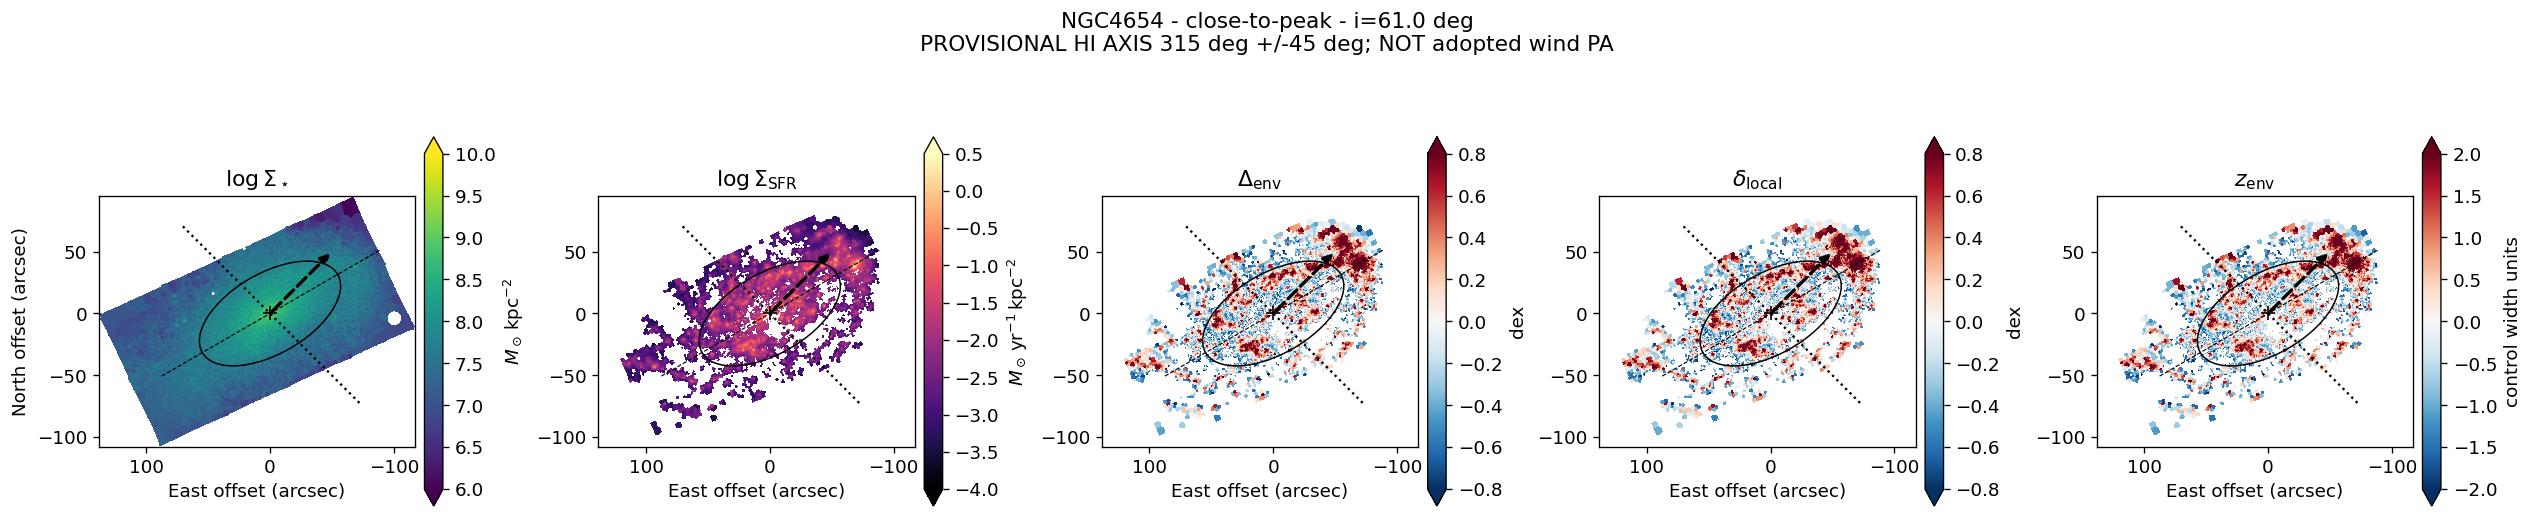

**Map interpretation -- NGC4654:** the supported environmental median is -0.035 dex (342,929 environmental pixels; 342,926 local pixels). The local map removes the galaxy-specific stellar-density trend; red patches there do not by themselves imply enhancement above the pre-peak control. **Any dashed arrow is only the literature-derived compass hypothesis; see the exploratory tests, not a primary wind result.**

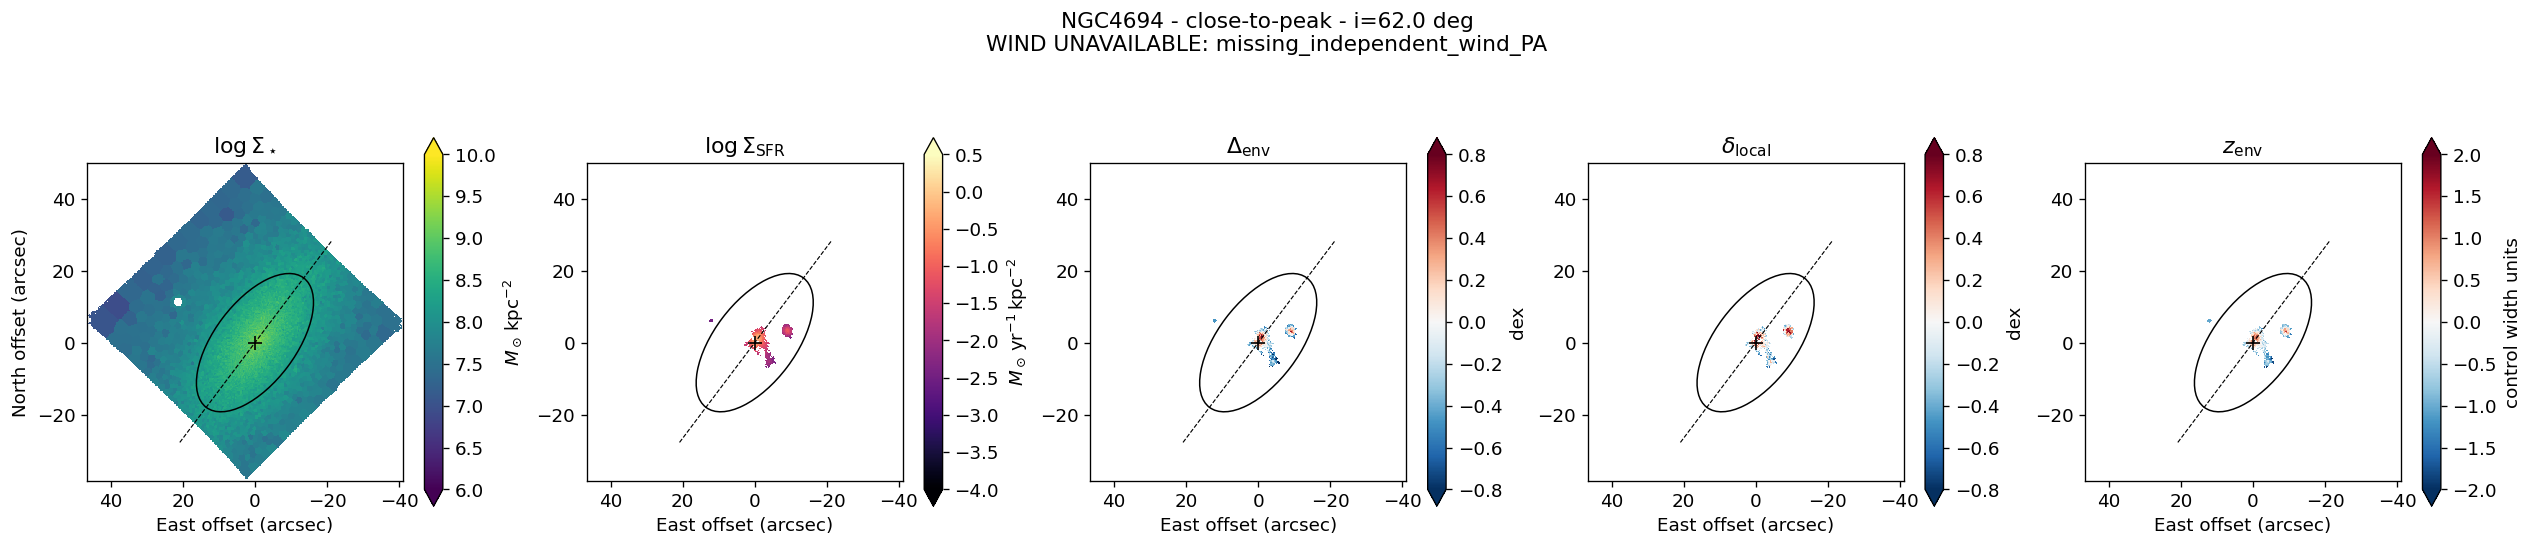

**Map interpretation -- NGC4694:** the supported environmental median is -0.162 dex (1,058 environmental pixels; 963 local pixels). The local map removes the galaxy-specific stellar-density trend; red patches there do not by themselves imply enhancement above the pre-peak control. **Any dashed arrow is only the literature-derived compass hypothesis; see the exploratory tests, not a primary wind result.**

,GALID,N_environment,N_local,median_environment,wind_status
0,NGC4298,144157,144120,-0.138488,PROVISIONAL HI AXIS 135 deg +/-45 deg; NOT ado...
1,NGC4424,8994,8868,-0.039562,PROVISIONAL HI AXIS 0 deg +/-45 deg; NOT adopt...
2,NGC4501,251936,251898,-0.242075,PROVISIONAL HI AXIS 225 deg +/-45 deg; NOT ado...
3,NGC4654,342929,342926,-0.034693,PROVISIONAL HI AXIS 315 deg +/-45 deg; NOT ado...
4,NGC4694,1058,963,-0.162338,WIND UNAVAILABLE: missing_independent_wind_PA


In [9]:
from matplotlib.patches import Ellipse


def decorate_map(ax, maps, direction):
    c = maps['components'].iloc[0]
    pa = np.deg2rad(c.pa_deg_east_of_north)
    extent = max(c.a_re_arcsec, 0.4*max(np.ptp(maps['east']), np.ptp(maps['north'])))
    ax.add_patch(Ellipse((0,0), 2*c.a_re_arcsec, 2*c.b_re_arcsec,
        angle=90-c.pa_deg_east_of_north, fill=False, edgecolor='black', lw=0.9))
    ax.plot([-extent*np.sin(pa), extent*np.sin(pa)],
            [-extent*np.cos(pa), extent*np.cos(pa)], '--', color='black', lw=0.7)
    ax.plot(0,0,'+',color='black',ms=8,mew=1)
    if direction.direction_usable or direction.get('exploratory_axis', False):
        wp = np.deg2rad(direction.pa_upwind_deg)
        length = 0.7*extent
        ax.annotate('', xy=(length*np.sin(wp), length*np.cos(wp)), xytext=(0,0),
            arrowprops=dict(arrowstyle='-|>', color='black', lw=2,
                linestyle='--' if direction.get('exploratory_axis', False) else '-'))
        ax.plot([-extent*np.cos(wp), extent*np.cos(wp)],
                [extent*np.sin(wp), -extent*np.sin(wp)], ':', color='black', lw=1.4)
    ax.set_aspect('equal')
    ax.set_xlabel('East offset (arcsec)')
    ax.invert_xaxis()


map_ids = list(spatial) if SHOW_ALL_STAGE_MAPS else close_ids
map_gallery_rows = []
for galid in map_ids:
    maps = spatial[galid]
    if len(maps['components']) != 1:
        print(f'{galid}: multi-centre gallery deferred; residual arrays are available in spatial.')
        continue
    direction = wind_status.loc[wind_status.GALID.eq(galid)].iloc[0].copy()
    candidate = VIVA_CANDIDATES.loc[VIVA_CANDIDATES.GALID.eq(galid)]
    direction['exploratory_axis'] = False
    if not direction.direction_usable and RUN_VIVA_EXPLORATORY and len(candidate):
        direction['pa_upwind_deg'] = candidate.pa_upwind_deg.iloc[0]
        direction['exploratory_axis'] = True
    valid, sf = maps['valid_disc_mask'], maps['sf_mask']
    panel_data = [np.where(valid, maps['log_sigma_star'], np.nan),
                  np.where(sf, maps['log_sigma_sfr'], np.nan),
                  maps['delta_env'], maps['delta_local'], maps['z_env']]
    labels = [r'$\log\Sigma_\star$', r'$\log\Sigma_{\rm SFR}$',
              r'$\Delta_{\rm env}$', r'$\delta_{\rm local}$', r'$z_{\rm env}$']
    ranges = [(6,10),(-4,0.5),(-RESIDUAL_VLIM,RESIDUAL_VLIM),
              (-RESIDUAL_VLIM,RESIDUAL_VLIM),(-Z_VLIM,Z_VLIM)]
    cmaps = ['viridis','magma','RdBu_r','RdBu_r','RdBu_r']
    units = [r'$M_\odot\,{\rm kpc}^{-2}$', r'$M_\odot\,{\rm yr}^{-1}\,{\rm kpc}^{-2}$',
             'dex','dex','control width units']
    fig, axes = plt.subplots(1,5,figsize=(21,4.8),layout='constrained')
    for ax, data, label, limits, cmap, unit in zip(axes,panel_data,labels,ranges,cmaps,units):
        im=ax.pcolormesh(maps['east'], maps['north'], np.ma.masked_invalid(data),
                        shading='nearest',cmap=cmap,vmin=limits[0],vmax=limits[1],rasterized=True)
        decorate_map(ax,maps,direction)
        ax.set_title(label)
        fig.colorbar(im,ax=ax,shrink=0.72,pad=0.02,extend='both',label=unit)
    axes[0].set_ylabel('North offset (arcsec)')
    wind_label = (f'upwind PA={direction.pa_upwind_deg:.1f} deg ({direction.quality}); nominal direction'
                  if direction.direction_usable else
                  f'PROVISIONAL HI AXIS {direction.pa_upwind_deg:.0f} deg +/-45 deg; NOT adopted wind PA'
                  if direction.exploratory_axis else 'WIND UNAVAILABLE: '+direction.direction_status)
    fig.suptitle(f'{galid} - {maps["stage"]} - i={maps["inclination"]:.1f} deg\n{wind_label}',fontsize=13)
    plt.show()
    nenv=np.count_nonzero(np.isfinite(maps['delta_env']))
    nlocal=np.count_nonzero(np.isfinite(maps['delta_local']))
    median_env=np.nanmedian(maps['delta_env'])
    map_gallery_rows.append(dict(GALID=galid,N_environment=nenv,N_local=nlocal,
                                 median_environment=median_env,wind_status=wind_label))
    from IPython.display import Markdown
    display(Markdown(f'**Map interpretation -- {galid}:** the supported environmental median is '
        f'{median_env:+.3f} dex ({nenv:,} environmental pixels; {nlocal:,} local pixels). '
        'The local map removes the galaxy-specific stellar-density trend; red patches there '
        'do not by themselves imply enhancement above the pre-peak control. '
        + ('The arrow is independent; side contrasts below test its alignment, subject to footprint and PA uncertainty.'
           if direction.direction_usable else
           '**Any dashed arrow is only the literature-derived compass hypothesis; see the exploratory tests, not a primary wind result.**')))
map_gallery_summary = pd.DataFrame(map_gallery_rows)
display(map_gallery_summary)


## 9. Nominal sky-plane hemispheres and per-galaxy contrasts

The pixel PA is $\operatorname{atan2}(E,N)$ (east of north). Leading pixels have
$\cos(PA_{\rm pixel}-PA_{\rm upwind})>0$, trailing pixels have the opposite
sign; the centre and exact boundary are excluded. No wind deprojection is used.

For each side on the common support, report $M_{\rm env}$, $M_{\rm local}$,
$f_{\rm enh}=P(z>1)$ and $f_{\rm sup}=P(z<-1)$; also show $|z|>2$ fractions.
Each contrast $A_X=X_{\rm lead}-X_{\rm trail}$. At least 20 common pixels per
side are required; counts describe support, not independent measurements.
Environmental-only side metrics have their own counts and are not substituted
for unsupported common-mask contrasts.

In [10]:
def side_metrics(pixel_pa, delta_env, delta_local, z_env, wind_pa, min_side=MIN_SIDE_PIXELS):
    pa, env, local, z = [np.asarray(v, dtype=float).ravel()
                        for v in (pixel_pa,delta_env,delta_local,z_env)]
    if not (pa.shape == env.shape == local.shape == z.shape):
        raise ValueError('Directional arrays must have matching shapes.')
    if not np.isfinite(wind_pa):
        raise ValueError('Physical wind PA is missing; no directional split is permitted.')
    cos_angle=np.cos(np.deg2rad(pa-wind_pa))
    half={'lead':cos_angle>1e-12, 'trail':cos_angle<-1e-12}
    env_support=np.isfinite(pa)&np.isfinite(env)&np.isfinite(z)
    joint=env_support&np.isfinite(local)
    result={}
    names=('M_env','M_local','f_enh','f_sup','f_strong_enh','f_strong_sup')
    for side,mask in half.items():
        use=joint&mask
        n=int(use.sum())
        result[f'N_joint_{side}']=n
        values=(np.median(env[use]),np.median(local[use]),np.mean(z[use]>1),
                np.mean(z[use]<-1),np.mean(z[use]>2),np.mean(z[use]<-2)) if n>=min_side else [np.nan]*6
        result.update({f'{name}_{side}':float(v) for name,v in zip(names,values)})
        full=env_support&mask
        result[f'N_env_all_{side}']=int(full.sum())
        result[f'M_env_all_{side}']=float(np.median(env[full])) if full.sum()>=min_side else np.nan
        result[f'f_enh_all_{side}']=float(np.mean(z[full]>1)) if full.sum()>=min_side else np.nan
    for short,name in [('env','M_env'),('local','M_local'),('enh','f_enh'),('sup','f_sup'),
                       ('strong_enh','f_strong_enh'),('strong_sup','f_strong_sup')]:
        result[f'A_{short}']=result[f'{name}_lead']-result[f'{name}_trail']
    result['side_supported']=min(result['N_joint_lead'],result['N_joint_trail'])>=min_side
    return result


metric_rows=[]
for d in wind_status.loc[wind_status.direction_usable & wind_status.in_first_pass].itertuples(index=False):
    m=spatial[d.GALID]
    rec=side_metrics(m['pixel_pa'],m['delta_env'],m['delta_local'],m['z_env'],d.pa_upwind_deg)
    rec.update(GALID=d.GALID,stage=d.stage,pa_upwind_deg=d.pa_upwind_deg,
               quality=d.quality,reference=d.reference,uncertainty_kind=d.uncertainty_kind)
    metric_rows.append(rec)
direction_metrics=pd.DataFrame(metric_rows)
if direction_metrics.empty:
    print('NOT COMPUTED: no independent eligible directions in the first-pass sample.')
    display(wind_status.loc[wind_status.in_first_pass,['GALID','stage','direction_status']])
else:
    display(direction_metrics)


NOT COMPUTED: no independent eligible directions in the first-pass sample.


,GALID,stage,direction_status
6,NGC4298,close-to-peak,missing_independent_wind_PA
14,NGC4424,close-to-peak,missing_independent_wind_PA
17,NGC4501,close-to-peak,missing_independent_wind_PA
23,NGC4654,close-to-peak,missing_independent_wind_PA
24,NGC4694,close-to-peak,missing_independent_wind_PA


## 10. Paired leading/trailing residuals

Paired points retain galaxy identity using `MAUVE_galaxy_colors.dat`. These
are per-galaxy descriptive estimates. No spaxel bootstrap or error bar assuming
independent neighbouring pixels is used.

In [11]:
galaxy_colors=load_galaxy_colors(GALAXY_COLOR_PATH)
if direction_metrics.empty or not direction_metrics.side_supported.any():
    print('Paired plot withheld: no direction-ready galaxy has supported measurements.')
else:
    fig,axes=plt.subplots(1,2,figsize=(12,5),layout='constrained')
    for ax,key,title in zip(axes,('M_env','M_local'),('Environmental residual','Internal residual')):
        for rec in direction_metrics.loc[direction_metrics.side_supported].itertuples(index=False):
            ax.plot([0,1],[getattr(rec,key+'_trail'),getattr(rec,key+'_lead')],'-o',
                    color=galaxy_colors[rec.GALID],label=rec.GALID)
        ax.axhline(0,color='0.5',lw=1,ls='--')
        ax.set_xticks([0,1],['Trailing','Leading'])
        ax.set(ylabel='Median residual (dex)',title=title)
    axes[1].legend(fontsize=8)
    plt.show()
    display(Markdown('**Interpretation:** a positive leading-minus-trailing contrast means '
        'a relatively stronger leading side. Only the environmental panel indicates whether '
        'that side is above the pre-peak control. Neither the sign nor the nominal contrast '
        'alone proves RPS triggering; test alignment below and propagate PA uncertainty later.'))


Paired plot withheld: no direction-ready galaxy has supported measurements.


## 11. Random-angle spin test: preserve the observed maps

For each eligible close-to-peak galaxy, keep its maps, masks and spatial
correlations fixed and draw 10,000 independent PAs uniformly on [0,360).
Recalculate $A_{\rm local}$, $A_{\rm env}$ and $A_{\rm enh}$, using the same
hemisphere support threshold as for the actual independent PA.

The prespecified positive-alignment test is
$p_+=(1+\#\{A^{\rm random}\geq A^{\rm obs}\})/(1+N_{\rm valid})$;
also report the two-sided absolute-contrast tail. These Monte Carlo tail
probabilities are conditional on angles with adequate support. The valid-angle
fraction is therefore reported; fewer than 90% valid angles, fewer than 100 valid
draws, or unsupported observed sides withhold a reportable p-value.

An incomplete/asymmetric footprint can still bias directional measurements.
A spin test tests the specialness of the chosen direction **within the observed
footprint**, not proof of compression or causation. Do not select the wind PA
that maximises the residual contrast. Missing physical directions do not get
random surrogate observations.

In [12]:
def spin_test(pixel_pa, delta_env, delta_local, z_env, observed_pa,
              n_spins=N_SPINS, seed=RANDOM_SEED, min_side=MIN_SIDE_PIXELS):
    pa,env,local,z=[np.asarray(v,dtype=float).ravel() for v in
                    (pixel_pa,delta_env,delta_local,z_env)]
    joint=np.isfinite(pa)&np.isfinite(env)&np.isfinite(local)&np.isfinite(z)
    pa,env,local,z=pa[joint],env[joint],local[joint],z[joint]
    observed=side_metrics(pa,env,local,z,observed_pa,min_side)
    keys=('A_local','A_env','A_enh')
    rng=np.random.default_rng(seed)
    angles=rng.uniform(0,360,n_spins)
    draws=np.full((n_spins,len(keys)),np.nan)
    # Work only on finite joint support. No data are resampled or shuffled spatially.
    for k,angle in enumerate(angles):
        c=np.cos(np.deg2rad(pa-angle))
        lead,trail=c>1e-12,c<-1e-12
        if min(lead.sum(),trail.sum()) < min_side:
            continue
        draws[k]=[np.median(local[lead])-np.median(local[trail]),
                  np.median(env[lead])-np.median(env[trail]),
                  np.mean(z[lead]>1)-np.mean(z[trail]>1)]
    rows=[]
    for j,key in enumerate(keys):
        finite=draws[np.isfinite(draws[:,j]),j]
        fraction=len(finite)/n_spins
        reportable=(observed['side_supported'] and len(finite)>=MIN_VALID_SPINS
                    and fraction>=MIN_SPIN_VALID_FRACTION)
        obs=observed[key]
        rows.append(dict(metric=key,observed=obs,N_spins=n_spins,N_valid=len(finite),
            valid_angle_fraction=fraction,reportable=reportable,
            p_spin_positive=(1+np.count_nonzero(finite>=obs))/(1+len(finite)) if reportable else np.nan,
            p_spin_two_sided=(1+np.count_nonzero(np.abs(finite)>=abs(obs)))/(1+len(finite)) if reportable else np.nan,
            null_p16=np.percentile(finite,16) if len(finite) else np.nan,
            null_p50=np.percentile(finite,50) if len(finite) else np.nan,
            null_p84=np.percentile(finite,84) if len(finite) else np.nan))
    return pd.DataFrame(rows),draws


spin_rows=[]
spin_draws={}
if not direction_metrics.empty:
    for rec in direction_metrics.itertuples(index=False):
        if not rec.side_supported:
            continue
        m=spatial[rec.GALID]
        summary,draws=spin_test(m['pixel_pa'],m['delta_env'],m['delta_local'],m['z_env'],
            rec.pa_upwind_deg,seed=RANDOM_SEED+sum(map(ord,rec.GALID)))
        summary.insert(0,'GALID',rec.GALID)
        spin_rows.append(summary)
        spin_draws[rec.GALID]=draws
        print(f'{rec.GALID}: {N_SPINS:,} random angles completed.')
spin_summary=pd.concat(spin_rows,ignore_index=True) if spin_rows else pd.DataFrame()
if spin_summary.empty:
    print('Physical spin tests NOT COMPUTED: independent wind PA or side support is missing.')
else:
    display(spin_summary)
    for galid,draws in spin_draws.items():
        fig,axes=plt.subplots(1,3,figsize=(14,3.6),layout='constrained')
        for j,(ax,key) in enumerate(zip(axes,('A_local','A_env','A_enh'))):
            values=draws[np.isfinite(draws[:,j]),j]
            s=spin_summary.loc[spin_summary.GALID.eq(galid)&spin_summary.metric.eq(key)].iloc[0]
            if len(values): ax.hist(values,bins=40,color='0.75',density=True)
            ax.axvline(s.observed,color=galaxy_colors[galid],lw=2,label='Independent PA')
            ax.set(title=f'{key}: p+={s.p_spin_positive:.3g}',xlabel='Leading - trailing',ylabel='Random-angle density')
        fig.suptitle(galid+' -- fixed-map random-angle null')
        plt.show()
        display(Markdown('**Spin-test interpretation:** a small positive-tail probability means '
            'the independent upwind direction gives an unusually positive contrast relative '
            'to random axes through this same observed map. It does not establish absolute '
            'enhancement, and nominal-PA probabilities do not incorporate direction uncertainty. '
            'Multiple galaxies and metrics are exploratory comparisons, without a multiplicity correction.'))


Physical spin tests NOT COMPUTED: independent wind PA or side support is missing.


## 11b. Exploratory VIVA-axis contrasts and sector sensitivity

This is the same first-pass hemisphere/spin calculation, evaluated at coarse
literature-morphology hypotheses. It is kept separate from `direction_metrics`
and **does not create primary wind results**. For each candidate, compute the
nominal contrast and spin null, then evaluate 19 equally spaced PAs across the
full +/-45 degree sector. Report the min/max and sign stability across that
sector, not a confidence interval. No optimisation or preferred-angle selection
from these curves is allowed.

The complete fixed-map random-angle null is reused for each sector point. This
provides conditional $p_+$ values for the assumed axes; these are not PA-marginalised
probabilities and are not evidence of wind alignment when the wind itself is
unconfirmed. The envelope is a coarse sensitivity grid, not a guarantee about
every angle between grid points. Effects may also reflect unequal mass/radius
coverage, which remains a later matching check.

NGC4298: provisional-axis 10,000-spin test and 19-angle sector check completed.
NGC4424: provisional-axis 10,000-spin test and 19-angle sector check completed.
NGC4501: provisional-axis 10,000-spin test and 19-angle sector check completed.
NGC4654: provisional-axis 10,000-spin test and 19-angle sector check completed.


,N_joint_lead,M_env_lead,M_local_lead,f_enh_lead,f_sup_lead,f_strong_enh_lead,f_strong_sup_lead,N_env_all_lead,M_env_all_lead,f_enh_all_lead,N_joint_trail,M_env_trail,M_local_trail,f_enh_trail,f_sup_trail,f_strong_enh_trail,f_strong_sup_trail,N_env_all_trail,M_env_all_trail,f_enh_all_trail,A_env,A_local,A_enh,A_sup,A_strong_enh,A_strong_sup,side_supported,GALID,assumed_pa_deg,caveat,status
0,88521,-0.115570,0.010810,0.117746,0.167520,0.019216,0.002508,88549,-0.115570,0.117969,55599,-0.168160,-0.033237,0.077519,0.194752,0.008399,0.003166,55608,-0.168160,0.077507,0.052590,0.044046,0.040227,-0.027232,0.010816,-0.000658,True,NGC4298,135.0,Nearby companion; tidal ambiguity,PROVISIONAL compass-axis test
1,4836,0.011574,0.047860,0.206576,0.129859,0.081679,0.002275,4894,0.010597,0.205149,4032,-0.094156,-0.081264,0.158730,0.170635,0.038690,0.000000,4100,-0.090158,0.158049,0.105729,0.129124,0.047846,-0.040776,0.042989,0.002275,True,NGC4424,0.0,Merger/collision; curved tail,PROVISIONAL compass-axis test
2,130825,-0.227387,0.029581,0.060401,0.234665,0.009624,0.004273,130825,-0.227387,0.060401,121073,-0.257945,-0.029786,0.045890,0.252988,0.005170,0.004254,121111,-0.257868,0.046189,0.030559,0.059368,0.014512,-0.018323,0.004453,0.000019,True,NGC4501,225.0,Chung SW/SE wording conflict; no measured PA,PROVISIONAL compass-axis test
3,172581,0.035710,0.064462,0.227140,0.109334,0.075002,0.000070,172583,0.035710,0.227137,170345,-0.094265,-0.063684,0.142493,0.175902,0.025824,0.006798,170346,-0.094265,0.142492,0.129974,0.128146,0.084647,-0.066568,0.049178,-0.006728,True,NGC4654,315.0,Mixed ram pressure and gravitational interaction,PROVISIONAL compass-axis test


,GALID,metric,observed,N_spins,N_valid,valid_angle_fraction,reportable,p_spin_positive,p_spin_two_sided,null_p16,null_p50,null_p84,status
0,NGC4298,A_local,0.044046,10000,10000,1.0,True,0.193281,0.382062,-0.047795,-0.000109,0.047795,Conditional on provisional compass PA; NOT pri...
1,NGC4298,A_env,0.052590,10000,10000,1.0,True,0.223178,0.444756,-0.055345,0.000764,0.055897,Conditional on provisional compass PA; NOT pri...
2,NGC4298,A_enh,0.040227,10000,10000,1.0,True,0.252075,0.508849,-0.041608,0.000361,0.041423,Conditional on provisional compass PA; NOT pri...
3,NGC4424,A_local,0.129124,10000,10000,1.0,True,0.125187,0.250575,-0.115917,0.000000,0.116147,Conditional on provisional compass PA; NOT pri...
4,NGC4424,A_env,0.105729,10000,10000,1.0,True,0.107089,0.213879,-0.083839,0.000696,0.084569,Conditional on provisional compass PA; NOT pri...
5,NGC4424,A_enh,0.047846,10000,10000,1.0,True,0.191181,0.382162,-0.056788,-0.000812,0.057082,Conditional on provisional compass PA; NOT pri...
6,NGC4501,A_local,0.059368,10000,10000,1.0,True,0.122288,0.255074,-0.055720,-0.000103,0.054333,Conditional on provisional compass PA; NOT pri...
7,NGC4501,A_env,0.030559,10000,10000,1.0,True,0.214079,0.438856,-0.033238,-0.002146,0.033021,Conditional on provisional compass PA; NOT pri...
8,NGC4501,A_enh,0.014512,10000,10000,1.0,True,0.235576,0.475352,-0.016456,-0.000133,0.016445,Conditional on provisional compass PA; NOT pri...
9,NGC4654,A_local,0.128146,10000,10000,1.0,True,0.190381,0.372163,-0.131275,0.001940,0.132530,Conditional on provisional compass PA; NOT pri...


,GALID,metric,minimum,maximum,N_supported_angles,p_positive_min,p_positive_max,positive_on_all_grid_angles
0,NGC4298,A_enh,0.035370,0.047689,19,0.025597,0.383162,True
1,NGC4298,A_env,0.048512,0.070323,19,0.017398,0.332667,True
2,NGC4298,A_local,0.026111,0.073499,19,0.023498,0.366563,True
3,NGC4424,A_enh,-0.012026,0.115384,19,0.005499,0.506949,False
4,NGC4424,A_env,-0.042961,0.168934,19,0.010899,0.684032,False
5,NGC4424,A_local,-0.035437,0.227755,19,0.006599,0.586741,False
6,NGC4501,A_enh,-0.000977,0.023651,19,0.001600,0.527847,False
7,NGC4501,A_env,0.005791,0.046111,19,0.014399,0.437056,True
8,NGC4501,A_local,-0.000878,0.081426,19,0.017698,0.512049,False
9,NGC4654,A_enh,0.070044,0.093290,19,0.005699,0.396260,True


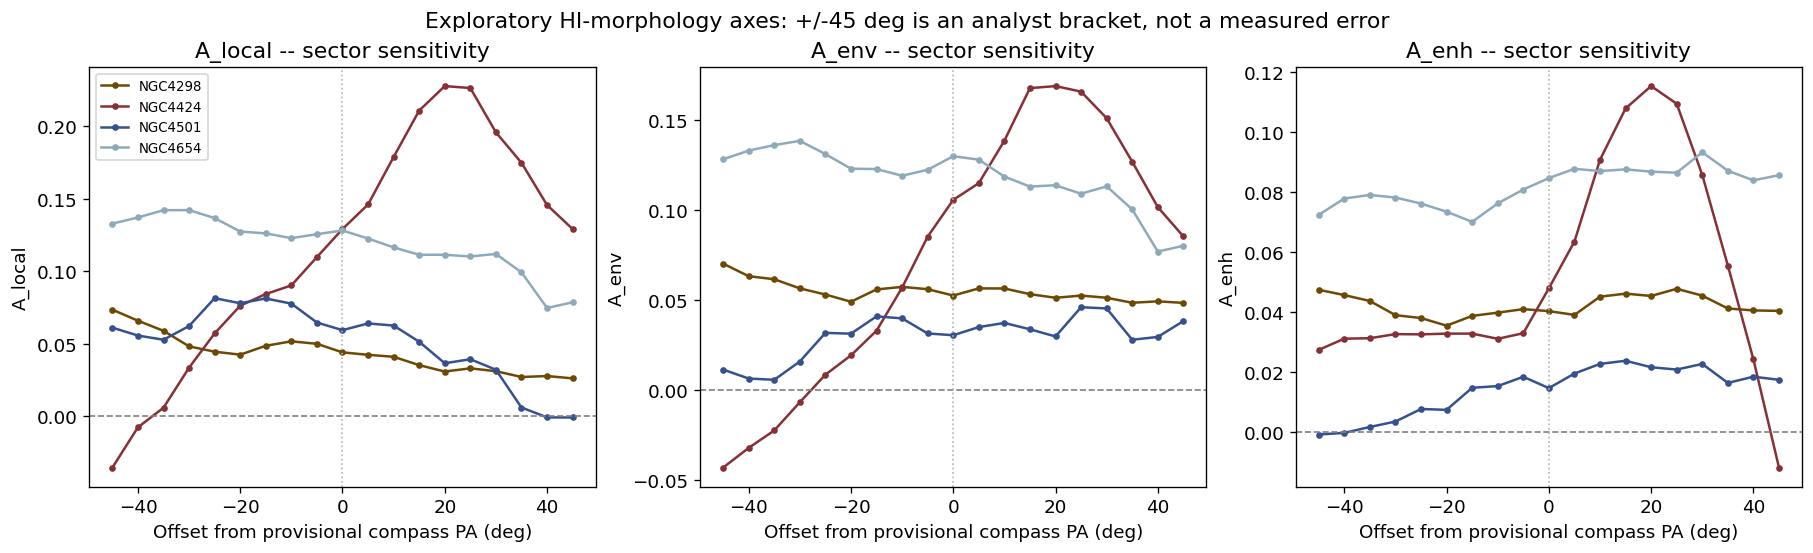

**Interpretation:** a curve crossing zero is sensitive even to these coarse direction choices. A sign retained across the sampled sector is more stable, but neither validates the proposed wind axis nor separates tides from ram pressure. Read the environmental side medians before calling any positive internal contrast enhancement above the control.

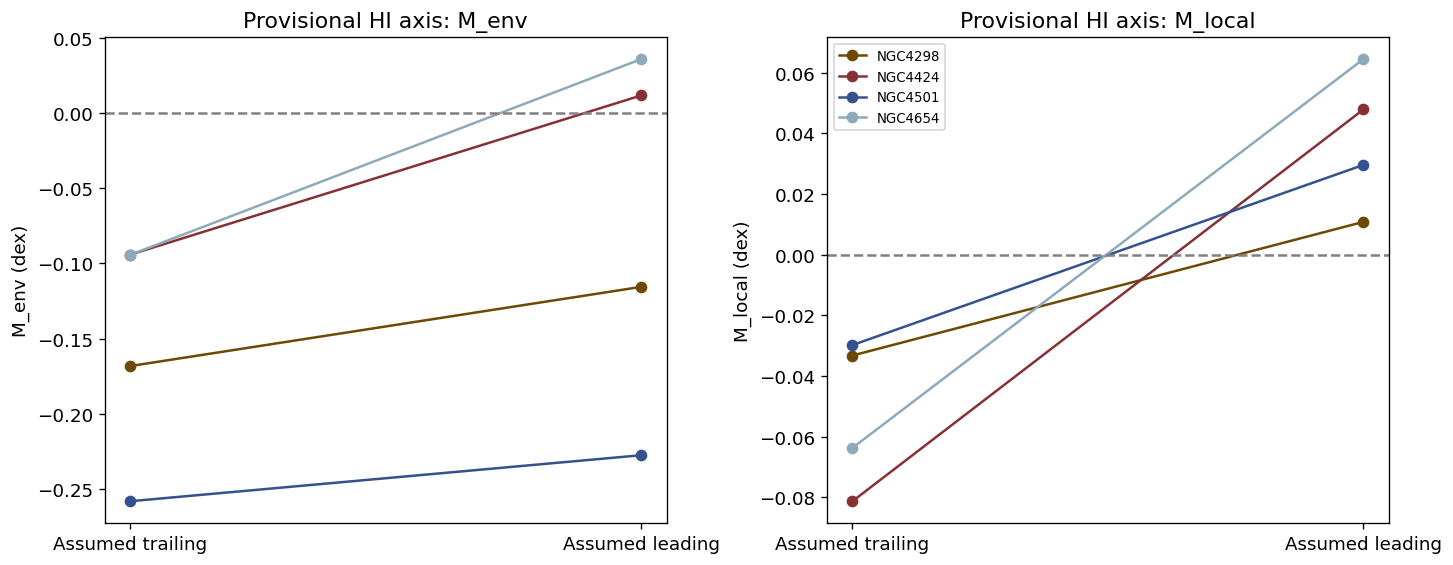

**Interpretation:** these pairs use the nominal compass centres only. Positive local asymmetry and a negative environmental leading median describe relative differential suppression, not enhancement above pre-peak. NGC4694 has no pair because its HI extension is not assigned a wind origin.

In [13]:
viva_metric_rows, viva_spin_rows, viva_sector_rows = [], [], []
viva_draws = {}
if RUN_VIVA_EXPLORATORY:
    for row in VIVA_CANDIDATES.itertuples(index=False):
        if row.GALID not in close_ids:
            continue
        maps = spatial[row.GALID]
        args = [maps[k] for k in ('pixel_pa','delta_env','delta_local','z_env')]
        nominal = side_metrics(*args, row.pa_upwind_deg)
        nominal.update(GALID=row.GALID, assumed_pa_deg=row.pa_upwind_deg,
                       caveat=row.caveat, status='PROVISIONAL compass-axis test')
        viva_metric_rows.append(nominal)
        if not nominal['side_supported']:
            print(row.GALID, ': insufficient common hemisphere support; spin test withheld')
            continue
        summary, draws = spin_test(*args, row.pa_upwind_deg,
            seed=RANDOM_SEED+sum(map(ord,row.GALID)))
        summary.insert(0,'GALID',row.GALID)
        summary['status'] = 'Conditional on provisional compass PA; NOT primary'
        viva_spin_rows.append(summary)
        viva_draws[row.GALID] = draws
        for offset in np.linspace(-row.half_width_deg,row.half_width_deg,19):
            pa = (row.pa_upwind_deg+offset)%360
            stat = side_metrics(*args,pa)
            for j,key in enumerate(('A_local','A_env','A_enh')):
                null = draws[np.isfinite(draws[:,j]),j]
                usable = (np.isfinite(stat[key]) and len(null)>=MIN_VALID_SPINS
                          and len(null)/N_SPINS>=MIN_SPIN_VALID_FRACTION)
                viva_sector_rows.append(dict(GALID=row.GALID,metric=key,offset_deg=offset,
                    assumed_pa_deg=pa,value=stat[key],
                    p_positive_conditional=(1+np.count_nonzero(null>=stat[key]))/(1+len(null)) if usable else np.nan))
        print(f'{row.GALID}: provisional-axis {N_SPINS:,}-spin test and 19-angle sector check completed.')

viva_metrics = pd.DataFrame(viva_metric_rows)
viva_spin_summary = pd.concat(viva_spin_rows,ignore_index=True) if viva_spin_rows else pd.DataFrame()
viva_sector = pd.DataFrame(viva_sector_rows)
viva_sector_summary = pd.DataFrame()
if not viva_metrics.empty:
    display(viva_metrics)
if not viva_spin_summary.empty:
    display(viva_spin_summary)
if not viva_sector.empty:
    viva_sector_summary = viva_sector.groupby(['GALID','metric'],as_index=False).agg(
        minimum=('value','min'),maximum=('value','max'),N_supported_angles=('value','count'),
        p_positive_min=('p_positive_conditional','min'),p_positive_max=('p_positive_conditional','max'))
    viva_sector_summary['positive_on_all_grid_angles'] = (
        viva_sector_summary.minimum.gt(0) & viva_sector_summary.N_supported_angles.eq(19))
    display(viva_sector_summary)
    fig,axes=plt.subplots(1,3,figsize=(15,4.5),layout='constrained')
    for ax,key in zip(axes,('A_local','A_env','A_enh')):
        for galid,g in viva_sector.loc[viva_sector.metric.eq(key)].groupby('GALID'):
            ax.plot(g.offset_deg,g.value,'o-',ms=3,color=galaxy_colors[galid],label=galid)
        ax.axhline(0,color='0.5',ls='--',lw=1)
        ax.axvline(0,color='0.7',ls=':',lw=1)
        ax.set(xlabel='Offset from provisional compass PA (deg)',ylabel=key,
               title=key+' -- sector sensitivity')
    axes[0].legend(fontsize=8)
    fig.suptitle('Exploratory HI-morphology axes: +/-45 deg is an analyst bracket, not a measured error')
    plt.show()
    display(Markdown('**Interpretation:** a curve crossing zero is sensitive even to '
        'these coarse direction choices. A sign retained across the sampled sector is '
        'more stable, but neither validates the proposed wind axis nor separates tides '
        'from ram pressure. Read the environmental side medians before calling any '
        'positive internal contrast enhancement above the control.'))
    fig,axes=plt.subplots(1,2,figsize=(12,4.6),layout='constrained')
    for ax,key in zip(axes,('M_env','M_local')):
        for row in viva_metrics.loc[viva_metrics.side_supported].itertuples(index=False):
            ax.plot([0,1],[getattr(row,key+'_trail'),getattr(row,key+'_lead')],'-o',
                    color=galaxy_colors[row.GALID],label=row.GALID)
        ax.axhline(0,color='0.5',ls='--')
        ax.set_xticks([0,1],['Assumed trailing','Assumed leading'])
        ax.set(ylabel=key+' (dex)',title='Provisional HI axis: '+key)
    axes[1].legend(fontsize=8)
    plt.show()
    display(Markdown('**Interpretation:** these pairs use the nominal compass centres '
        'only. Positive local asymmetry and a negative environmental leading median '
        'describe relative differential suppression, not enhancement above pre-peak. '
        'NGC4694 has no pair because its HI extension is not assigned a wind origin.'))
else:
    print('No exploratory VIVA-axis results: disabled or insufficient data.')

## 12. Reproducibility checks and first-pass synthesis

In [14]:
assert set(spatial)==set(q4_sample.GALID)
assert not map_support.GALID.duplicated().any()
for galid,m in spatial.items():
    assert np.all(~m['joint_mask'] | m['environment_mask'])
    assert np.all(~m['environment_mask'] | m['sf_mask'])
    original=spaxels[galid]
    np.testing.assert_array_equal(m['delta_env'][np.isfinite(m['delta_env'])],
                                  original['delta'][np.isfinite(original['delta'])])
    np.testing.assert_array_equal(m['z_env'][np.isfinite(m['z_env'])],
                                  original['z'][np.isfinite(original['z'])])

ready=wind_status.loc[wind_status.in_first_pass & wind_status.direction_usable]
missing=wind_status.loc[wind_status.in_first_pass & ~wind_status.direction_usable]
print('PASS: Q3 residual vectors match the reconstructed spatial maps exactly.')
print('Eligible Q3 products:',len(spatial),'| close-to-peak map targets:',len(close_ids))
print('Independent nominal directions ready:',len(ready))
if len(missing):
    print('Direction input required for:',', '.join(missing.GALID))
print('External figure/table saving:',SAVE_OUTPUTS)

if direction_metrics.empty:
    display(Markdown('### Current first-pass result\n\n'
        'The environmental and within-galaxy residual maps are available, with the '
        'Q3 selection and environmental residuals preserved. **There is no test of '
        'adopted-wind alignment yet:** the primary direction catalogue is missing. '
        'The separate VIVA tests above use provisional morphology axes only. No primary spin-test significance, triggering, or absence of a '
        'directional effect is inferred from this missing input.'))
else:
    interpretation_rows=[]
    for rec in direction_metrics.itertuples(index=False):
        p=np.nan
        if not spin_summary.empty:
            s=spin_summary.loc[spin_summary.GALID.eq(rec.GALID)&spin_summary.metric.eq('A_local')]
            if len(s): p=s.p_spin_positive.iloc[0]
        if not rec.side_supported:
            description='Insufficient common support on one or both sides'
        elif rec.A_local>0 and rec.M_env_lead>0:
            description='Positive internal contrast; leading median above control (candidate, not proof of triggering)'
        elif rec.A_local>0 and rec.M_env_lead<=0 and rec.A_env>0:
            description='Leading side relatively stronger, but still at/below control; differential suppression candidate'
        elif rec.A_local>0:
            description='Positive local contrast but environmental contrast disagrees; inspect density support'
        else:
            description='No positive internal leading contrast at the adopted PA; not evidence of equivalence'
        interpretation_rows.append(dict(GALID=rec.GALID,description=description,p_spin_positive=p,
            uncertainty_status='Nominal PA only; uncertainty propagation deferred'))
    interpretation_table=pd.DataFrame(interpretation_rows)
    display(interpretation_table)
    display(Markdown('### Current first-pass result\n\n'
        'The table separates the sign of internal asymmetry from enhancement above '
        'the control. These are descriptive candidates, not causal classifications. '
        'Evaluate spin probabilities together with effect sizes, map coverage, and '
        'independent direction quality. PA uncertainty has not been propagated.'))


if not viva_metrics.empty:
    print('\nExploratory compass-axis snapshot (not adopted physical wind results):')
    for row in viva_metrics.itertuples(index=False):
        print(f'{row.GALID}: A_local={row.A_local:+.3f} dex; A_env={row.A_env:+.3f} dex; '
              f'A_enh={row.A_enh:+.3f}; M_env,lead={row.M_env_lead:+.3f} dex')


PASS: Q3 residual vectors match the reconstructed spatial maps exactly.
Eligible Q3 products: 26 | close-to-peak map targets: 5
Independent nominal directions ready: 0
Direction input required for: NGC4298, NGC4424, NGC4501, NGC4654, NGC4694
External figure/table saving: False

Exploratory compass-axis snapshot (not adopted physical wind results):
NGC4298: A_local=+0.044 dex; A_env=+0.053 dex; A_enh=+0.040; M_env,lead=-0.116 dex
NGC4424: A_local=+0.129 dex; A_env=+0.106 dex; A_enh=+0.048; M_env,lead=+0.012 dex
NGC4501: A_local=+0.059 dex; A_env=+0.031 dex; A_enh=+0.015; M_env,lead=-0.227 dex
NGC4654: A_local=+0.128 dex; A_env=+0.130 dex; A_enh=+0.085; M_env,lead=+0.036 dex


### Current first-pass result

The environmental and within-galaxy residual maps are available, with the Q3 selection and environmental residuals preserved. **There is no test of adopted-wind alignment yet:** the primary direction catalogue is missing. The separate VIVA tests above use provisional morphology axes only. No primary spin-test significance, triggering, or absence of a directional effect is inferred from this missing input.

### Verification of this saved run

- All 14 code cells executed in the ICRAR Python environment; seven PNG figures are embedded.
- No stored errors or stderr warnings in the final run; all seven figures inspected visually.
- The source Q3 notebook SHA-256 is unchanged. Embedded Q3 helper ASTs, inventory and control code were compared to the live source.
- Reconstructed environmental and standardised residuals match Q3 arrays exactly for all 26 eligible products.
- Independent synthetic checks cover cardinal PAs, 180-degree sign reversal, boundary exclusion, missing-PA rejection, support thresholds, local-reference gaps, a zero-map null and the analytical hemisphere-median plateau for a cosine field.
- Four provisional axes each received 10,000 fixed-map random-angle draws and a 19-angle sector scan. No FITS products, source notebooks or external plot/table files were changed.

The numerical execution verifies implementation, not the physical correctness of a provisional wind axis.

## Final scientific synthesis and decision point

This first pass distinguishes two questions: whether a surviving SF region lies
above/below the pre-peak population, and whether it lies above/below the typical
relation within its own galaxy. Only an independent wind direction can turn
those maps into a test of RPS-aligned asymmetry. A leading side that is less
suppressed is physically different from one above the environmental control.

**Missing data are not a null result.** Read the generated status immediately
above: absent/ineligible PAs withhold directional inference. The catalogue input
cell accepts sourced PAs without changing any SF masks or refitting to the wind
direction. Rerun from that cell after supplying it; earlier residual maps do not
depend on wind inputs.

If this first pass reveals coherent alignment, the shared plan's later work is:
PA-uncertainty propagation, inclination/selection checks, matched density/radius
support, angular profiles, dipoles, radial dependence, spatial SF survival, and
whole-galaxy bootstrap/permutation stage comparisons. They are not performed or
claimed here. The independent sampling unit for any future stage comparison
remains the galaxy; pixels and gas bins are spatially correlated.

The VIVA evidence section and its separate provisional-axis experiment are a
completed exploratory extension of steps 1--8. Compass sectors are recorded
explicitly; they must not be presented as measured wind PAs. In particular,
NGC4694's catalogue stage is not itself evidence that its H I extension is
ram-pressure debris. Its direction is withheld without removing it from Q3.


### Executed exploratory result (2026-08-30)

| Galaxy | Assumed upwind PA | A_local (dex) | M_env,lead (dex) | Conditional spin p+ for A_local | A_local across sector (dex) |
|---|---:|---:|---:|---:|---:|
| NGC4298 | 135 deg | +0.044 | -0.116 | 0.193 | +0.026 to +0.073 |
| NGC4424 | 0 deg | +0.129 | +0.012 | 0.125 | -0.035 to +0.228 |
| NGC4501 | 225 deg | +0.059 | -0.227 | 0.122 | -0.001 to +0.081 |
| NGC4654 | 315 deg | +0.128 | +0.036 | 0.190 | +0.075 to +0.142 |

All four nominal compass axes give positive internal contrasts, but none of the three prespecified contrast statistics in any galaxy has a nominal positive-tail spin probability below 0.05. Every random angle meets the pixel support threshold for these four maps. This is not evidence of equivalence or proof that directional structure is absent; it means the coarse proposed axes are not especially unusual under this hemisphere-median/fraction test.

NGC4298 and NGC4654 remain positive in all three contrast metrics across the 19-point sector grid. NGC4424 changes sign; NGC4501 retains positive environmental contrast but its local and enhanced-fraction contrasts reach slightly negative values. NGC4298 and NGC4501 have negative environmental medians on both nominal sides: their positive contrast describes differential suppression. NGC4424 and NGC4654 have only slightly positive nominal leading environmental medians (+0.012 and +0.036 dex), not a demonstrated triggering signal.

**Do not pick the angle with the smallest p-value in the sector scan.** These minima are not prespecified tests and carry an angle-selection penalty. The sector is an analyst sensitivity bracket, not a measured uncertainty distribution. The source ambiguity, possible tides, internal control, finite footprint and unmatched radial sampling remain limits on physical interpretation.

The practical next decision is to establish defensible wind directions for the promising cases before expanding to stage stacks or interpreting a causal RPS signal. NGC4694 stays in the Q3 sample and map gallery, with no RPS wind direction assigned from its accretion-related H I morphology.